# Hidden Markov Model (HMM) Analysis
### Master Thesis: Revisiting Delegation Theory in the Age of AI: Dynamic Algorithm Appreciation and Aversion in Triadic Organizational Relationships

---

### Table of Contents

**Part I — Data and HMM Estimation Framework**

1. [Data Description and Variable Construction](#1-data-description-and-variable-construction)
   - 1.1 &nbsp; [Helpers & Imports](#11-helpers--imports)
   - 1.2 &nbsp; [Benchmark Construction](#12-benchmark-construction)
   - 1.3 &nbsp; [Data Loading & Inspection](#13-data-loading--inspection)
2. [Hidden Markov Model Specification](#2-hidden-markov-model-specification)
   - 2.1 &nbsp; [Model Structure & Forward–Backward Algorithm](#21-model-structure--22-forwardbackward-algorithm)
   - 2.2 &nbsp; [Maximum Likelihood Estimation](#22-maximum-likelihood-estimation)
3. [Model Selection and Parameter Estimation](#3-model-selection-and-parameter-estimation)
4. [Posterior State Inference and Interpretation](#4-posterior-state-inference-and-interpretation)
   - 4.1 &nbsp; [Posterior State Assignment](#41-posterior-state-assignment)
   - 4.2 &nbsp; [Results Visualisation](#42-results-visualisation)

**Part II — Empirical Findings**

5. [KPI-Driven Transition Dynamics](#5-kpi-driven-transition-dynamics)
6. [Transparency as Moderator of State Transitions](#6-transparency-as-moderator-of-state-transitions)
7. [Strategic Control Retention Under High Task Stakes](#7-strategic-control-retention-under-high-task-stakes)

**Part III — Theoretical and Task-Level Implications**

8. [Delegation as Dynamic Learning Process](#8-delegation-as-dynamic-learning-process)
9. [Authority as Strategic and Legitimacy Mechanism](#9-authority-as-strategic-and-legitimacy-mechanism)
10. [Triadic Delegation Flows: Authority vs Execution](#10-triadic-delegation-flows-authority-vs-execution)
11. [Temporal Evolution of Delegation Patterns](#11-temporal-evolution-of-delegation-patterns)

**Appendix**

12. [Cluster Bootstrap Standard Errors](#12-cluster-bootstrap-standard-errors)
13. [Model Summary Table](#13-model-summary-table)

---
# Part I — Data and HMM Estimation Framework

<a id="1-data-description-and-variable-construction"></a>
## 1. Data Description and Variable Construction
<a id="11-helpers--imports"></a>
### 1.1 Helpers & Imports

In [2]:
# ============================================================
# 1. Imports & Helpers
# ============================================================
from __future__ import annotations

import os
import time
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple
from pathlib import Path
from multiprocessing.pool import ThreadPool

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import logsumexp
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

# ---- resolve data path ----
MANUAL_XLSX_PATH = None
PREFERRED_DATASETS = [
    Path(r"..\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx"),
]
DATA_PATH = None
if MANUAL_XLSX_PATH:
    DATA_PATH = Path(MANUAL_XLSX_PATH)
else:
    for p in PREFERRED_DATASETS:
        if p.exists():
            DATA_PATH = p
            break
assert DATA_PATH is not None and DATA_PATH.exists(), \
    f"Data file not found. Tried: {PREFERRED_DATASETS}"
print(f"Data file: {DATA_PATH.resolve()}")


def softmax(z, axis=-1):
    """Numerically stable softmax (works on 1-D vectors and row-wise on 2-D)."""
    z = z - np.max(z, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)


def log_softmax(z, axis=-1):
    """Numerically stable log-softmax."""
    return z - logsumexp(z, axis=axis, keepdims=True)


def log_gaussian_diag(y, mean, log_sigma):
    """Scalar version (kept for reference)."""
    sigma2 = np.exp(2 * log_sigma)
    return -0.5 * (
        np.sum(np.log(2 * np.pi * sigma2))
        + np.sum((y - mean) ** 2 / sigma2)
    )

print("Section 1 — Imports & helpers loaded.")

Data file: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx
Section 1 — Imports & helpers loaded.


<a id="12-benchmark-construction"></a>
### 1.2 Benchmark Construction
Derive performance benchmarks used as **transition covariates**:
- `kpi_operational_gap_index` — composite operational KPIs gap
- `within_unit_temporal_benchmark` — period-over-period KPIs change
- `horizontal_peer_benchmark` — cross-sectional percentile, rank percentile within period
- `within_unit_ai_trajectory_benchmark` — deviation from low-AI baseline (periods with low AI delegation)
- `threshold_benchmark` — recent negative shock indicator, e.g. missing a KPI target, a self-service level breach or forecast failure in the preceding period.

In [20]:
# ============================================================
# 2. Build Benchmarks
# ============================================================

def build_benchmarks(df):
    df = df.sort_values(["manager_id", "period_id"]).copy()

    # Composite performance index (higher = better)
    df["kpi_operational_gap_index"] = (
        (-1.0) * df["service_level_delta"]
        + (-0.6) * df["inventory_cost_delta"]
        + (-0.4) * df["expedite_cost_delta"]
        + (-1.2) * df["error_incident_count"]
    )

    # Within-manager temporal benchmark
    df["within_unit_temporal_benchmark"] = (
        df.groupby("manager_id")["kpi_operational_gap_index"].diff(1)
    )

    # Peer percentile (cross-sectional)
    pct = df.groupby("period_id")["kpi_operational_gap_index"].rank(pct=True)
    df["horizontal_peer_benchmark"] = (pct - 0.5) * 2.0

    # AI trajectory benchmark
    def ai_traj(g):
        q = g["ai_decision_authority_share"].quantile(0.30)
        base = g.loc[
            g["ai_decision_authority_share"] <= q,
            "kpi_operational_gap_index",
        ].mean()
        if np.isnan(base):
            base = g["kpi_operational_gap_index"].mean()
        return g["kpi_operational_gap_index"] - base

    df["within_unit_ai_trajectory_benchmark"] = (
        df.groupby("manager_id", group_keys=False).apply(ai_traj)
    )

    # Threshold shock
    df["threshold_benchmark"] = df["recent_negative_shock"].astype(float)

    # ── Transparency main effect ─────────────────────────────────────────────
    # Normalise transparency level to [0, 1] (original: 0–3)
    df["transparency_level_norm"] = df["transparency_level"].astype(float) / 3.0

    # ── Transparency × Performance interactions ──────────────────────────────
    # These enter the transition equation: they capture whether the effect
    # of a performance signal on state transitions is moderated by how
    # transparent the AI was in that period.
    df["transparency_x_operational"] = (
        df["transparency_level_norm"] * df["kpi_operational_gap_index"]
    )
    df["transparency_x_temporal"] = (
        df["transparency_level_norm"] * df["within_unit_temporal_benchmark"]
    )

    return df

print("Section 2 — build_benchmarks() defined.")


Section 2 — build_benchmarks() defined.


<a id="13-data-loading--inspection"></a>
### 1.3 Data Loading & Inspection
Load the `panel_manager_period` sheet, build benchmarks, scale variables, and form per-manager sequences.

In [21]:
# ============================================================
# 3. Data Loader
# ============================================================

@dataclass
class HMMData:
    Y: List[np.ndarray]      # emission sequences
    X: List[np.ndarray]      # transition covariates
    Z: List[np.ndarray]      # emission controls
    ids: List[str]
    periods: List[np.ndarray]
    y_scaler: StandardScaler
    x_scaler: StandardScaler
    z_scaler: StandardScaler


def load_sequences(xlsx_path):
    df = pd.read_excel(xlsx_path, sheet_name="panel_manager_period")

    # Safety: analysis file should NOT contain latent truth columns
    forbidden = ["latent_state_true", "latent_state_true_next"]
    if any(c in df.columns for c in forbidden):
        df = df.drop(columns=[c for c in forbidden if c in df.columns])
        print("  Dropped latent truth columns to proceed with analysis data.")

    df = build_benchmarks(df)

    # ── Compute share_authority_esc from decision_episode ──
    dec_ep = pd.read_excel(xlsx_path, sheet_name="decision_episode")
    dec_ep["is_escalated"] = (dec_ep["escalation_flag"] == 1).astype(int)
    esc_agg = (dec_ep
        .groupby(["manager_id", "period_id"])
        .agg(n_tasks=("episode_id", "count"),
             n_escalated=("is_escalated", "sum"))
        .reset_index())
    esc_agg["share_authority_esc"] = esc_agg["n_escalated"] / esc_agg["n_tasks"]
    df = df.merge(esc_agg[["manager_id", "period_id", "share_authority_esc"]],
                  on=["manager_id", "period_id"], how="left")
    df["share_authority_esc"] = df["share_authority_esc"].fillna(0.0)
    print(f"  share_authority_esc computed from decision_episode "
          f"(mean={df['share_authority_esc'].mean():.4f}, "
          f"std={df['share_authority_esc'].std():.4f})")

    emission_cols = ["ai_decision_authority_share", "override_rate",
                     "share_authority_esc"]

    transition_cols = [
        # ── Core performance benchmarks ──
        "within_unit_temporal_benchmark",
        "horizontal_peer_benchmark",
        "within_unit_ai_trajectory_benchmark",
        "threshold_benchmark",
        # ── Transparency main effect ──
        # transparency_level_norm: normalised 0-3 → 0-1 per-period AI transparency
        "transparency_level_norm",
        # ── Transparency × Performance interactions ──
        # Captures whether transparency moderates the performance→state pathway
        "transparency_x_operational",   # transparency_level_norm × kpi_operational_gap_index
        "transparency_x_temporal",      # transparency_level_norm × within_unit_temporal_benchmark
    ]

    control_cols = [
        "task_complexity_index",
        "demand_volatility",
        "supply_disruption_count",
        "forecast_accuracy_mape",
        "decision_latency_avg",
        "target_difficulty",
        "performance_pressure_index",
        "recent_negative_shock",
    ]

    df = df.dropna(subset=emission_cols + transition_cols + control_cols)

    Y_list, X_list, Z_list = [], [], []
    ids, periods = [], []

    for mid, g in df.groupby("manager_id"):
        g = g.sort_values("period_id")
        Y = g[emission_cols].to_numpy(float)
        X = g[transition_cols].to_numpy(float)
        Z = g[control_cols].to_numpy(float)
        if len(Y) < 3:
            continue
        Y_list.append(Y)
        X_list.append(X)
        Z_list.append(Z)
        ids.append(mid)
        periods.append(g["period_id"].to_numpy())

    y_scaler = StandardScaler().fit(np.vstack(Y_list))
    x_scaler = StandardScaler().fit(np.vstack(X_list))
    z_scaler = StandardScaler().fit(np.vstack(Z_list))

    Y_list = [y_scaler.transform(y) for y in Y_list]
    X_list = [x_scaler.transform(x) for x in X_list]
    Z_list = [z_scaler.transform(z) for z in Z_list]

    return HMMData(Y_list, X_list, Z_list, ids, periods,
                   y_scaler, x_scaler, z_scaler)


# ---- Load & inspect ----
data = load_sequences(DATA_PATH)

seq_lens = [len(y) for y in data.Y]
print(f"Managers loaded : {len(data.Y)}")
print(f"Total observations: {sum(seq_lens)}")
print(f"Sequence lengths : min={min(seq_lens)}, median={int(np.median(seq_lens))}, max={max(seq_lens)}")
print(f"Emission dims (D) : {data.Y[0].shape[1]}")
print(f"Trans. covars (P) : {data.X[0].shape[1]}  "
      f"(4 benchmarks + 1 transparency main effect + 2 interactions = 7)")
print(f"Controls (K)      : {data.Z[0].shape[1]}")


  Dropped latent truth columns to proceed with analysis data.


C:\Users\Admin\AppData\Local\Temp\ipykernel_26872\389222393.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("manager_id", group_keys=False).apply(ai_traj)


  share_authority_esc computed from decision_episode (mean=0.1853, std=0.0690)
Managers loaded : 120
Total observations: 3000
Sequence lengths : min=25, median=25, max=25
Emission dims (D) : 3
Trans. covars (P) : 7  (4 benchmarks + 1 transparency main effect + 2 interactions = 7)
Controls (K)      : 8


<a id="2-hidden-markov-model-specification"></a>
## 2. Hidden Markov Model Specification
<a id="21-model-structure--22-forwardbackward-algorithm"></a>
### 2.1 Model Structure & 2.2 Forward–Backward Algorithm

In [22]:
# ============================================================
# Pre-stack all sequences to 3-D tensors for batched estimation
# ============================================================
import numpy as np

Y_stack = np.stack(data.Y)   # (N, T, D)
X_stack = np.stack(data.X)   # (N, T, P)
Z_stack = np.stack(data.Z)   # (N, T, K)

N, T, D = Y_stack.shape
P = X_stack.shape[2]
K = Z_stack.shape[2]
n_obs_total = N * T

print(f"Stacked arrays:")
print(f"  Y_stack: {Y_stack.shape}  (N={N}, T={T}, D={D})")
print(f"  X_stack: {X_stack.shape}  (N={N}, T={T}, P={P})")
print(f"  Z_stack: {Z_stack.shape}  (N={N}, T={T}, K={K})")
print(f"  n_obs_total = {n_obs_total}")

Stacked arrays:
  Y_stack: (120, 25, 3)  (N=120, T=25, D=3)
  X_stack: (120, 25, 7)  (N=120, T=25, P=7)
  Z_stack: (120, 25, 8)  (N=120, T=25, K=8)
  n_obs_total = 3000


In [23]:
# ── X collinearity check ─────────────────────────────────────────────────────
transition_cols_check = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "within_unit_ai_trajectory_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
    "transparency_x_operational",
    "transparency_x_temporal",
]

X_flat = X_stack.reshape(-1, X_stack.shape[-1])   # (N*T, 7)
corr = np.corrcoef(X_flat.T)
df_corr = pd.DataFrame(corr, index=transition_cols_check, columns=transition_cols_check)

def color_high(val):
    return "background-color: #ff4444; color: white" if abs(val) >= 0.80 and abs(val) < 1.0 else ""

display(df_corr.round(3).style.map(color_high))

print("\nPairs with |r| >= 0.70:")
found = False
for i in range(len(transition_cols_check)):
    for j in range(i+1, len(transition_cols_check)):
        r = corr[i, j]
        if abs(r) >= 0.70:
            print(f"  {transition_cols_check[i]:40s}  {transition_cols_check[j]:40s}  r={r:.3f}")
            found = True
if not found:
    print("  None — all pairs below 0.70 ✓")


,within_unit_temporal_benchmark,horizontal_peer_benchmark,within_unit_ai_trajectory_benchmark,threshold_benchmark,transparency_level_norm,transparency_x_operational,transparency_x_temporal
within_unit_temporal_benchmark,1.000000,0.680000,0.699000,-0.006000,-0.007000,0.415000,0.807000
horizontal_peer_benchmark,0.680000,1.000000,0.899000,0.003000,-0.000000,0.544000,0.532000
within_unit_ai_trajectory_benchmark,0.699000,0.899000,1.000000,-0.000000,0.030000,0.539000,0.567000
threshold_benchmark,-0.006000,0.003000,-0.000000,1.000000,0.028000,-0.027000,0.005000
transparency_level_norm,-0.007000,-0.000000,0.030000,0.028000,1.000000,-0.690000,-0.012000
transparency_x_operational,0.415000,0.544000,0.539000,-0.027000,-0.690000,1.000000,0.519000
transparency_x_temporal,0.807000,0.532000,0.567000,0.005000,-0.012000,0.519000,1.000000



Pairs with |r| >= 0.70:
  within_unit_temporal_benchmark            transparency_x_temporal                   r=0.807
  horizontal_peer_benchmark                 within_unit_ai_trajectory_benchmark       r=0.899


In [24]:
# ============================================================
# 4. Parameters + Forward–Backward  (VECTORIZED)
# ============================================================

@dataclass
class Params:
    logit_pi: np.ndarray   # (J,)
    alpha: np.ndarray      # (J, J)
    beta: np.ndarray       # (J, J, P)
    mu: np.ndarray         # (J, D)
    W: np.ndarray          # (J, D, K)
    log_sigma: np.ndarray  # (J, D)


def _precompute(p, Y, X, Z):
    """Shared emission + transition pre-computation."""
    T, D = Y.shape
    J = p.mu.shape[0]
    means = p.mu[None, :, :] + np.einsum('jdk,tk->tjd', p.W, Z)
    residuals = Y[:, None, :] - means
    sigma2 = np.exp(2 * p.log_sigma)
    log_norm = np.sum(np.log(2 * np.pi * sigma2), axis=1)
    logB = -0.5 * (log_norm[None, :] +
                   np.sum(residuals ** 2 / sigma2[None, :, :], axis=2))
    logits_all = (p.alpha[None, :, :]
                  + np.einsum('ijp,tp->tij', p.beta, X))
    logQ_all = log_softmax(logits_all, axis=2)
    return T, J, logB, logQ_all


def forward_only(p, Y, X, Z):
    """Forward pass only — returns log-likelihood (no posterior). ~2× faster."""
    T, J, logB, logQ_all = _precompute(p, Y, X, Z)
    pi = softmax(p.logit_pi)
    log_alpha = np.empty((T, J))
    log_alpha[0] = np.log(pi) + logB[0]
    for t in range(1, T):
        log_alpha[t] = logB[t] + logsumexp(
            log_alpha[t - 1, :, None] + logQ_all[t], axis=0)
    return float(logsumexp(log_alpha[-1]))


def forward_backward(p, Y, X, Z):
    """Full forward–backward returning (ll, log_gamma)."""
    T, J, logB, logQ_all = _precompute(p, Y, X, Z)
    pi = softmax(p.logit_pi)
    log_alpha = np.empty((T, J))
    log_alpha[0] = np.log(pi) + logB[0]
    for t in range(1, T):
        log_alpha[t] = logB[t] + logsumexp(
            log_alpha[t - 1, :, None] + logQ_all[t], axis=0)
    ll = logsumexp(log_alpha[-1])

    log_beta = np.zeros((T, J))
    for t in reversed(range(T - 1)):
        log_beta[t] = logsumexp(
            logQ_all[t + 1] + logB[t + 1][None, :] + log_beta[t + 1][None, :],
            axis=1)

    log_gamma = log_alpha + log_beta
    log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
    return ll, log_gamma

print("Section 4 — Params, forward_only() & forward_backward() defined.")

Section 4 — Params, forward_only() & forward_backward() defined.


<a id="22-maximum-likelihood-estimation"></a>
### 2.2 Maximum Likelihood Estimation
Estimate models with 2–4 latent states via maximum likelihood using L-BFGS-B optimization. To mitigate local optima, we employ multiple random initializations and diagonal-biased transition logits. Model selection follows a two-stage procedure: a computationally efficient screening phase identifies the most promising state specification using BIC, followed by a high-precision refit of the selected model using extended iterations and warm-start initialization. The final model is chosen based on the lowest Bayesian Information Criterion.

In [17]:
# ============================================================
# 5. Batched MLE Estimator  (fit_model_batched)
# ============================================================
# Accepts Y_stack, X_stack, Z_stack as EXPLICIT parameters so
# that Stack dimensions are always consistent with what was passed.
# Supports do_emission_only_warmstart for a two-phase init.
# ============================================================

import time
import numpy as np
from scipy.optimize import minimize
from scipy.special import logsumexp, log_softmax


def fit_model_batched(
    J: int,
    Y_stack: np.ndarray,
    X_stack: np.ndarray,
    Z_stack: np.ndarray,
    *,
    maxiter: int = 600,
    n_starts: int = 5,
    seed: int = 7,
    sigma_min: float = 0.05,
    sigma_max: float = 5.0,
    time_cap_min: int = 15,
    print_every: int = 50,
    l2: float = 1e-4,
    diag_bias: float = 2.0,
    maxfun: int = 200_000,
    ftol: float = 1e-8,
    gtol: float = 5e-6,
    warm_starts: list | None = None,
    use_subset: bool = False,
    subset_size: int = 80,
    do_emission_only_warmstart: bool = True,
    emission_only_maxiter: int = 120,
    emission_only_maxfun: int = 60_000,
):
    """
    Batched NH-HMM fit with Gaussian emissions and covariate-dependent
    transitions via L-BFGS-B.

    Parameters
    ----------
    Y_stack : (N, T, D) emission data
    X_stack : (N, T, P) transition covariates
    Z_stack : (N, T, K) emission controls
    do_emission_only_warmstart : if True, first optimize emission params only
        (mu, W, log_sigma) with transitions fixed, then use as init.
    """
    # Derive dimensions from passed stacks
    N_full, T, D = Y_stack.shape
    P = X_stack.shape[2]
    K = Z_stack.shape[2]

    # Optional subset for speed
    if use_subset and N_full > subset_size:
        rng_sub = np.random.default_rng(seed)
        idx = rng_sub.choice(N_full, size=subset_size, replace=False)
        Y_use = Y_stack[idx]
        X_use = X_stack[idx]
        Z_use = Z_stack[idx]
        N_use = subset_size
    else:
        Y_use, X_use, Z_use = Y_stack, X_stack, Z_stack
        N_use = N_full

    # ── pack / unpack ──
    def pack(p):
        return np.concatenate([
            p.logit_pi.ravel(), p.alpha.ravel(), p.beta.ravel(),
            p.mu.ravel(), p.W.ravel(), p.log_sigma.ravel(),
        ])

    def unpack(theta):
        idx = 0
        def take(n):
            nonlocal idx; v = theta[idx:idx+n]; idx += n; return v
        return Params(
            logit_pi=take(J),
            alpha=take(J*J).reshape(J,J),
            beta=take(J*J*P).reshape(J,J,P),
            mu=take(J*D).reshape(J,D),
            W=take(J*D*K).reshape(J,D,K),
            log_sigma=take(J*D).reshape(J,D),
        )

    # ── bounds (log_sigma only) ──
    n_logit_pi = J
    n_alpha = J*J
    n_beta = J*J*P
    n_mu = J*D
    n_W = J*D*K
    n_log_sigma = J*D
    log_sigma_start = n_logit_pi + n_alpha + n_beta + n_mu + n_W
    log_sigma_end = log_sigma_start + n_log_sigma
    total_params = log_sigma_end

    LOW, HIGH = np.log(sigma_min), np.log(sigma_max)
    bounds = [(None, None)] * total_params
    for i in range(log_sigma_start, log_sigma_end):
        bounds[i] = (LOW, HIGH)

    # ── smart init ──
    Y_flat = Y_use.reshape(-1, D)
    y_mean = Y_flat.mean(axis=0)
    y_std = np.maximum(Y_flat.std(axis=0), 1e-3)

    def smart_init_params(rng):
        mu0 = y_mean[None,:] + rng.normal(0, 1.0, (J,D)) * y_std[None,:]
        log_sigma0 = np.log(np.clip(y_std, sigma_min, sigma_max))[None,:]
        log_sigma0 = np.repeat(log_sigma0, J, axis=0)
        log_sigma0 = np.clip(log_sigma0 + rng.normal(0, 0.12, (J,D)), LOW, HIGH)
        logit_pi0 = rng.normal(0, 0.2, J)
        alpha0 = rng.normal(0, 0.20, (J,J)) + np.eye(J) * diag_bias
        beta0 = rng.normal(0, 0.02, (J,J,P))
        W0 = rng.normal(0, 0.03, (J,D,K))
        return Params(logit_pi=logit_pi0, alpha=alpha0, beta=beta0,
                      mu=mu0, W=W0, log_sigma=log_sigma0)

    # ── neg-LL (batched forward algorithm) ──
    stop_flag = {"stop": False}

    def neg_ll(theta):
        if stop_flag["stop"]:
            return 1e50
        p = unpack(theta)
        log_pi = log_softmax(p.logit_pi, axis=0)
        means = p.mu[None,None,:,:] + np.einsum("jdk,ntk->ntjd", p.W, Z_use)
        resid = Y_use[:,:,None,:] - means
        sigma2 = np.maximum(np.exp(2.0 * p.log_sigma), 1e-6)
        log_norm = np.sum(np.log(2*np.pi * sigma2), axis=1)
        logB = -0.5 * (log_norm[None,None,:] +
                       np.sum(resid**2 / sigma2[None,None,:,:], axis=3))
        logQ = log_softmax(
            p.alpha[None,None,:,:] + np.einsum("ijp,ntp->ntij", p.beta, X_use),
            axis=3)
        la = log_pi[None,:] + logB[:,0,:]
        for t in range(1, T):
            la = logB[:,t,:] + logsumexp(la[:,:,None] + logQ[:,t,:,:], axis=1)
        ll = np.sum(logsumexp(la, axis=1))
        return -float(ll) if np.isfinite(ll) else 1e40

    def objective(theta):
        base = neg_ll(theta)
        if not np.isfinite(base) or l2 <= 0:
            return base if np.isfinite(base) else 1e40
        p = unpack(theta)
        pen = (np.sum(p.alpha**2) + np.sum(p.beta**2) +
               np.sum(p.W**2) + 0.10*np.sum(p.mu**2))
        return base + l2 * pen

    # ── emission-only warmstart objective ──
    def emission_only_objective(em_theta, fixed_logit_pi, fixed_alpha, fixed_beta):
        """Optimize only mu, W, log_sigma with transitions frozen."""
        idx = 0
        def take(n):
            nonlocal idx; v = em_theta[idx:idx+n]; idx += n; return v
        mu = take(J*D).reshape(J,D)
        W = take(J*D*K).reshape(J,D,K)
        log_sigma = take(J*D).reshape(J,D)
        p = Params(logit_pi=fixed_logit_pi, alpha=fixed_alpha,
                   beta=fixed_beta, mu=mu, W=W, log_sigma=log_sigma)
        theta_full = pack(p)
        return objective(theta_full)

    # ── multi-start optimization ──
    init_list = list(warm_starts) if warm_starts else []
    runs = []

    for s in range(n_starts):
        rng = np.random.default_rng(seed + s)
        stop_flag["stop"] = False

        # Initialize
        if s < len(init_list):
            p0 = init_list[s]
            # Ensure dimensions match
            if p0.W.shape != (J, D, K):
                print(f"  ⚠️  start {s+1}: warm start W shape {p0.W.shape} "
                      f"!= ({J},{D},{K}), using random init")
                p0 = smart_init_params(rng)
            else:
                p0 = Params(
                    logit_pi=p0.logit_pi + rng.normal(0, 0.03, J),
                    alpha=p0.alpha + rng.normal(0, 0.03, (J,J)),
                    beta=p0.beta + rng.normal(0, 0.008, (J,J,P)),
                    mu=p0.mu + rng.normal(0, 0.05, (J,D)),
                    W=p0.W + rng.normal(0, 0.01, (J,D,K)),
                    log_sigma=np.clip(p0.log_sigma + rng.normal(0, 0.02, (J,D)),
                                      LOW, HIGH),
                )
        else:
            p0 = smart_init_params(rng)

        # Phase 1 (optional): emission-only warmstart
        if do_emission_only_warmstart and s >= len(init_list):
            em_theta0 = np.concatenate([
                p0.mu.ravel(), p0.W.ravel(), p0.log_sigma.ravel()])
            em_bounds = ([(None,None)]*(J*D + J*D*K) +
                         [(LOW,HIGH)]*(J*D))
            em_res = minimize(
                emission_only_objective, em_theta0,
                args=(p0.logit_pi, p0.alpha, p0.beta),
                method="L-BFGS-B", bounds=em_bounds,
                options={"maxiter": emission_only_maxiter,
                         "maxfun": emission_only_maxfun})
            # unpack emission params back
            eidx = 0
            def etake(n):
                nonlocal eidx; v = em_res.x[eidx:eidx+n]; eidx += n; return v
            p0 = Params(logit_pi=p0.logit_pi, alpha=p0.alpha,
                        beta=p0.beta,
                        mu=etake(J*D).reshape(J,D),
                        W=etake(J*D*K).reshape(J,D,K),
                        log_sigma=etake(J*D).reshape(J,D))

        # Phase 2: full optimization
        theta0 = pack(p0)
        start_time = time.time()
        iter_counter = {"i": 0}

        def callback(_xk):
            iter_counter["i"] += 1
            if iter_counter["i"] % print_every == 0:
                elapsed_min = (time.time() - start_time) / 60
                print(f"    J={J} start {s+1}/{n_starts} "
                      f"iter={iter_counter['i']} elapsed={elapsed_min:.1f} min",
                      flush=True)
            if (time.time() - start_time) > time_cap_min * 60:
                stop_flag["stop"] = True

        res = minimize(objective, theta0, method="L-BFGS-B",
                       bounds=bounds, callback=callback,
                       options={"maxiter": maxiter, "maxfun": maxfun,
                                "ftol": ftol, "gtol": gtol})

        if stop_flag["stop"]:
            res.success = False
            res.message = f"Time cap reached ({time_cap_min} min)"

        true_negll = neg_ll(res.x)
        runs.append((unpack(res.x), res, true_negll))
        print(f"    done: J={J} start {s+1}/{n_starts} success={res.success} "
              f"nit={getattr(res,'nit',None)} true_negLL={true_negll:.2f} "
              f"msg={res.message}", flush=True)

    # ── pick best run ──
    converged = [(p,r,tnl) for (p,r,tnl) in runs if bool(r.success)]
    if converged:
        best_p, best_res, best_tnl = min(converged, key=lambda t: t[2])
        best_is_conv = True
    else:
        best_p, best_res, best_tnl = min(runs, key=lambda t: t[2])
        best_is_conv = False

    best_res.true_negll = best_tnl
    best_res.true_ll = -best_tnl
    best_res.k_params = len(best_res.x)
    return best_p, best_res, best_is_conv


print("fit_model_batched() defined — accepts Y_stack, X_stack, Z_stack explicitly.")

fit_model_batched() defined — accepts Y_stack, X_stack, Z_stack explicitly.


In [19]:
# ============================================================
# STAGE 1: SCREENING  (J = 2, 3, 4)
# Goal:
#   1) Subset warm-start for each J (Stage 1A)
#   2) Full-data fit for each J using warm start (Stage 1B)
#   3) Select best J by BIC
# ============================================================

import time
import numpy as np
import pandas as pd

# ----------------------------
# Helper: build configs by J
# ----------------------------
def make_cfg_stage1a(J: int) -> dict:
    """Subset screening configs to generate warm start."""
    if J == 2:
        return dict(
            maxiter=600,
            n_starts=6,
            time_cap_min=15,
            diag_bias=2.0,
            maxfun=220000,
            use_subset=False,
            subset_size=80,
            l2=0.01,
            ftol=1e-7,
            gtol=1e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=140,
        )
    if J == 3:
        return dict(
            maxiter=900,
            n_starts=10,
            time_cap_min=25,
            diag_bias=2.6,
            maxfun=380000,
            use_subset=True,
            subset_size=95,
            l2=0.01,
            ftol=1e-7,
            gtol=2e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=180,
        )
    # J == 4
    return dict(
        maxiter=1100,
        n_starts=12,
        time_cap_min=30,
        diag_bias=2.9,
        maxfun=520000,
        use_subset=True,
        subset_size=95,
        l2=0.01,
        ftol=1e-7,
        gtol=2e-5,
        do_emission_only_warmstart=True,
        emission_only_maxiter=220,
    )


def make_cfg_stage1b(J: int) -> dict:
    """Full-data screening configs seeded with subset warm starts."""
    if J == 2:
        return dict(
            maxiter=700,
            n_starts=6,
            time_cap_min=18,
            diag_bias=2.0,
            maxfun=260000,
            use_subset=False,
            l2=0.01,
            ftol=1e-7,
            gtol=1e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=140,
        )
    if J == 3:
        return dict(
            maxiter=1200,
            n_starts=10,
            time_cap_min=32,
            diag_bias=2.4,
            maxfun=520000,
            use_subset=False,
            l2=0.01,
            ftol=1e-7,
            gtol=2e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=200,
        )
    # J == 4
    return dict(
        maxiter=1500,
        n_starts=12,
        time_cap_min=40,
        diag_bias=2.7,
        maxfun=700000,
        use_subset=False,
        l2=0.01,
        ftol=1e-7,
        gtol=2e-5,
        do_emission_only_warmstart=True,
        emission_only_maxiter=260,
    )


# ----------------------------
# Stage 1A: Subset screening  (J = 2, 3, 4)
# ----------------------------
warm_by_J: dict[int, object] = {}
subset_log = []

print("\n=== STAGE 1A: Subset Screening — J = 2, 3, 4 ===")

for J in [2, 3, 4]:
    cfg = make_cfg_stage1a(J)

    print(f"\n[SubsetScreen] Fitting J={J} ...", flush=True)
    t0 = time.time()

    p_hat_sub, res_sub, is_conv_sub = fit_model_batched(
        J=J,
        Y_stack=Y_stack, X_stack=X_stack, Z_stack=Z_stack,
        seed=7,
        sigma_min=0.1, sigma_max=3.5,
        print_every=50,
        **cfg
    )

    elapsed = time.time() - t0
    warm_by_J[J] = p_hat_sub

    subset_log.append({
        "stage": "subset",
        "J": J,
        "soft_converged": bool(is_conv_sub),
        "scipy_success": bool(getattr(res_sub, "success", False)),
        "LL": float(getattr(res_sub, "true_ll", np.nan)),
        "time_s": elapsed,
        "message": str(getattr(res_sub, "message", "")),
    })

    print(
        f"[SubsetScreen] J={J} soft_converged={bool(is_conv_sub)} "
        f"LL={float(getattr(res_sub,'true_ll',np.nan)):.1f} "
        f"({elapsed/60:.1f} min) msg={getattr(res_sub,'message','')}",
        flush=True
    )

df_subset = pd.DataFrame(subset_log)
display(df_subset.round(2))


# ----------------------------
# Stage 1B: Full-data — J = 2, 3, 4
# ----------------------------
screen_results = []

print("\n=== STAGE 1B: Full-data Fit — J = 2, 3, 4 (warm-started) ===")

for J in [2, 3, 4]:
    cfg_full = make_cfg_stage1b(J)

    warm = warm_by_J.get(J)
    if warm is None:
        print(f"⚠️  No warm start for J={J}. Skipping full-data screening.")
        continue

    print(f"\n[ScreenFull] Fitting J={J} (warm-started) ...", flush=True)
    t0 = time.time()

    p_hat, res, is_conv = fit_model_batched(
        J=J,
        Y_stack=Y_stack, X_stack=X_stack, Z_stack=Z_stack,
        seed=77,
        sigma_min=0.1, sigma_max=3.5,
        print_every=50,
        warm_starts=[warm],
        **cfg_full
    )

    elapsed = time.time() - t0

    ll_total = float(getattr(res, "true_ll", np.nan))
    k_params = len(getattr(res, "x", []))

    bic = np.log(n_obs_total) * k_params - 2.0 * ll_total
    aic = 2.0 * k_params - 2.0 * ll_total

    screen_results.append({
        "stage": "screen_full",
        "J": J,
        "params": k_params,
        "LL": ll_total,
        "AIC": aic,
        "BIC": bic,
        "converged_soft": bool(is_conv),
        "converged_scipy": bool(getattr(res, "success", False)),
        "time_s": elapsed,
        "message": str(getattr(res, "message", "")),
    })

    sym = "✓" if bool(is_conv) else "✗"
    print(
        f"[ScreenFull] J={J} LL={ll_total:.1f} BIC={bic:.1f} params={k_params} "
        f"{sym} ({elapsed/60:.1f} min)"
    )
    print(f"            message: {getattr(res,'message','')}")

df_screen = pd.DataFrame(screen_results)
display(df_screen.round(2))


# ----------------------------
# Select best J by BIC
# ----------------------------
best_J_screen = int(df_screen.loc[df_screen["BIC"].idxmin(), "J"])
best_row = df_screen[df_screen["J"] == best_J_screen].iloc[0]
print(
    f"\n★ Best J by BIC: J={best_J_screen} "
    f"(BIC={best_row['BIC']:.1f}, soft_converged={bool(best_row['converged_soft'])})"
)
print(df_screen[["J", "params", "LL", "AIC", "BIC", "converged_soft"]].to_string(index=False))



=== STAGE 1A: Subset Screening — J = 2, 3, 4 ===

[SubsetScreen] Fitting J=2 ...
    J=2 start 1/6 iter=50 elapsed=0.7 min
    J=2 start 1/6 iter=100 elapsed=1.4 min
    J=2 start 1/6 iter=150 elapsed=2.2 min
    J=2 start 1/6 iter=200 elapsed=2.7 min
    done: J=2 start 1/6 success=True nit=202 true_negLL=1101.75 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 2/6 iter=50 elapsed=0.7 min
    J=2 start 2/6 iter=100 elapsed=1.4 min
    J=2 start 2/6 iter=150 elapsed=1.9 min
    J=2 start 2/6 iter=200 elapsed=2.5 min
    done: J=2 start 2/6 success=True nit=247 true_negLL=1101.75 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 3/6 iter=50 elapsed=0.9 min
    J=2 start 3/6 iter=100 elapsed=1.5 min
    J=2 start 3/6 iter=150 elapsed=2.2 min
    J=2 start 3/6 iter=200 elapsed=2.9 min
    J=2 start 3/6 iter=250 elapsed=3.5 min
    done: J=2 start 3/6 success=True nit=250 true_negLL=1101.75 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

,stage,J,soft_converged,scipy_success,LL,time_s,message
0,subset,2,True,True,-1.101750e+03,1464.42,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,subset,3,True,True,-2.072900e+02,11798.89,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
2,subset,4,False,False,-1.000000e+50,25760.70,Time cap reached (30 min)



=== STAGE 1B: Full-data Fit — J = 2, 3, 4 (warm-started) ===

[ScreenFull] Fitting J=2 (warm-started) ...
    J=2 start 1/6 iter=50 elapsed=0.6 min
    done: J=2 start 1/6 success=True nit=73 true_negLL=1101.75 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 2/6 iter=50 elapsed=0.6 min
    J=2 start 2/6 iter=100 elapsed=1.1 min
    J=2 start 2/6 iter=150 elapsed=1.6 min
    J=2 start 2/6 iter=200 elapsed=2.1 min
    done: J=2 start 2/6 success=True nit=201 true_negLL=1101.75 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 3/6 iter=50 elapsed=0.5 min
    J=2 start 3/6 iter=100 elapsed=1.1 min
    J=2 start 3/6 iter=150 elapsed=1.6 min
    J=2 start 3/6 iter=200 elapsed=2.1 min
    done: J=2 start 3/6 success=True nit=208 true_negLL=1101.75 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 4/6 iter=50 elapsed=0.5 min
    J=2 start 4/6 iter=100 elapsed=1.0 min
    J=2 start 4/6 iter=150 elapsed=1.6 min
    J=2 start 4/6 i

,stage,J,params,LL,AIC,BIC,converged_soft,converged_scipy,time_s,message
0,screen_full,2,94,-1.101750e+03,2.391500e+03,2.956100e+03,True,True,1103.05,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,screen_full,3,165,-2.267100e+02,7.834200e+02,1.774470e+03,True,True,8416.42,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
2,screen_full,4,252,-1.000000e+50,2.000000e+50,2.000000e+50,False,False,68766.98,Time cap reached (40 min)



★ Best J by BIC: J=3 (BIC=1774.5, soft_converged=True)
 J  params            LL          AIC          BIC  converged_soft
 2      94 -1.101749e+03 2.391499e+03 2.956097e+03            True
 3     165 -2.267094e+02 7.834189e+02 1.774470e+03            True
 4     252 -1.000000e+50 2.000000e+50 2.000000e+50           False


#### Final refit with best J!!!

In [25]:
# ============================================================
# STAGE 2: FINAL REFIT (robust version)
# ============================================================

import time
import numpy as np

# ----------------------------
# Select best J from Stage 1
# ----------------------------
if "best_J" in globals():
    BEST_J = int(best_J)
elif "best_J_screen" in globals():
    BEST_J = int(best_J_screen)
else:
    raise NameError("Run Stage 1 screening first.")

print(f"\n=== STAGE 2: FINAL REFIT (BEST J={BEST_J}) ===")

# ----------------------------
# Warm start
# Skip any warm start whose W shape doesn't match Z_stack K dimension
# ----------------------------
warm_list = []
K_now = Z_stack.shape[2]

for src_name, src_dict in [
    ("best_params_full_by_J", globals().get("best_params_full_by_J", {})),
    ("warm_by_J", globals().get("warm_by_J", {})),
]:
    if isinstance(src_dict, dict) and BEST_J in src_dict:
        ws = src_dict[BEST_J]
        if hasattr(ws, "W") and ws.W.shape[2] == K_now:
            warm_list.append(ws)
            print(f"✓ Using warm start from {src_name} (K={ws.W.shape[2]})")
            break
        else:
            ws_k = ws.W.shape[2] if hasattr(ws, "W") else "?"
            print(f"⚠️ Skipping warm start from {src_name} (K={ws_k} ≠ {K_now})")

if not warm_list:
    print("⚠️ No compatible warm start found — random initialization")

# ----------------------------
# Stronger final configuration
# NOTE: l2=0.01 prevents degenerate absorbing transitions
#       (previous l2=8e-5 allowed alpha logit diffs > 40)
# ----------------------------
final_cfg = dict(
    maxiter=1600,
    n_starts=12,
    seed=777,
    time_cap_min=45,
    diag_bias=2.4 if BEST_J <= 3 else 2.7,
    maxfun=900_000,
    use_subset=False,
    l2=0.01,
    do_emission_only_warmstart=True,
    emission_only_maxiter=300,
    ftol=1e-9,
    gtol=1e-6,
)

# ----------------------------
# Run final estimation
# ----------------------------
t0 = time.time()

best_p_final, best_res_final, best_is_conv_final = fit_model_batched(
    J=BEST_J,
    Y_stack=Y_stack,
    X_stack=X_stack,
    Z_stack=Z_stack,
    sigma_min=0.1,
    sigma_max=3.5,
    print_every=50,
    warm_starts=warm_list,
    **final_cfg
)

elapsed = time.time() - t0

# ----------------------------
# Metrics
# ----------------------------
ll_total = float(getattr(best_res_final, "true_ll", np.nan))
k_params = len(getattr(best_res_final, "x", []))
bic = np.log(n_obs_total) * k_params - 2.0 * ll_total
aic = 2.0 * k_params - 2.0 * ll_total

print("\n" + "="*60)
print(f"FINAL MODEL (J={BEST_J})")
print(f"LL:  {ll_total:.2f}")
print(f"AIC: {aic:.2f}")
print(f"BIC: {bic:.2f}")
print(f"Soft-converged: {bool(best_is_conv_final)}")
print(f"SciPy success:  {bool(getattr(best_res_final,'success',False))}")
print(f"Runtime: {elapsed/60:.1f} minutes")
print("="*60)

best_model = best_p_final


=== STAGE 2: FINAL REFIT (BEST J=3) ===
✓ Using warm start from warm_by_J (K=8)
    J=3 start 1/12 iter=50 elapsed=1.2 min
    J=3 start 1/12 iter=100 elapsed=2.4 min
    J=3 start 1/12 iter=150 elapsed=3.4 min
    J=3 start 1/12 iter=200 elapsed=4.6 min
    J=3 start 1/12 iter=250 elapsed=5.7 min
    J=3 start 1/12 iter=300 elapsed=6.9 min
    J=3 start 1/12 iter=350 elapsed=7.9 min
    J=3 start 1/12 iter=400 elapsed=8.9 min
    J=3 start 1/12 iter=450 elapsed=9.9 min
    J=3 start 1/12 iter=500 elapsed=11.0 min
    J=3 start 1/12 iter=550 elapsed=12.0 min
    J=3 start 1/12 iter=600 elapsed=13.5 min
    J=3 start 1/12 iter=650 elapsed=14.7 min
    J=3 start 1/12 iter=700 elapsed=16.1 min
    J=3 start 1/12 iter=750 elapsed=17.3 min
    J=3 start 1/12 iter=800 elapsed=18.6 min
    J=3 start 1/12 iter=850 elapsed=19.8 min
    J=3 start 1/12 iter=900 elapsed=21.1 min
    J=3 start 1/12 iter=950 elapsed=22.4 min
    J=3 start 1/12 iter=1000 elapsed=23.6 min
    J=3 start 1/12 iter=1050

In [26]:

import pickle

# Save best model artifacts for later reuse (no refit needed)

best_J = int(best_J) if "best_J" in globals() else int(globals().get("BEST_J", best_J_screen))

model_artifacts = {
    "best_model": best_model,
    "best_J": int(best_J),
    "best_res_final": globals().get("best_res_final", None),
    "final_cfg": globals().get("final_cfg", None),
    "ll_total": globals().get("ll_total", None),
    "k_params": globals().get("k_params", None),
    "n_obs_total": globals().get("n_obs_total", None),
    "aic": globals().get("aic", None),
    "bic": globals().get("bic", None),
    "emission_cols": globals().get("emission_cols", None),
    "transition_cols": globals().get("transition_cols", None),
    "control_cols": globals().get("control_cols", None),
    "label_map": globals().get("label_map", None),
    "state_order_1idx": globals().get("state_order_1idx", None),
    "y_scaler": getattr(data, "y_scaler", None),
    "x_scaler": getattr(data, "x_scaler", None),
    "z_scaler": getattr(data, "z_scaler", None),
}

out_path = Path("best_model_artifacts_v2.pkl")
with out_path.open("wb") as f:
    pickle.dump(model_artifacts, f)

print(f"Saved best model artifacts → {out_path.resolve()}")


Saved best model artifacts → C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\data_analysis\best_model_artifacts_v2.pkl


<a id="3-model-selection-and-parameter-estimation"></a>
## 3. Model Selection and Parameter Estimation


In [36]:
# ============================================================
# 6. Inspect Estimated Parameters  (UPDATED + REPORTABLE)
#   - Uses Stage 2 final model handles
#   - Adds: posterior occupancy + certainty (from gamma if available)
#   - Prints: transition probabilities (A) in addition to intercept logits (alpha)
#   - Keeps: emissions on original scale
# ============================================================

import numpy as np
import pandas as pd
from scipy.special import softmax

# --- Use Stage 2 final outputs ---
best_model = best_p_final
best_J = int(best_J_final) if "best_J_final" in globals() else int(BEST_J)

emission_cols = ["ai_decision_authority_share", "override_rate", "share_authority_esc"]

# ----------------------------
# Emissions (original scale)
# ----------------------------
mu_orig = data.y_scaler.inverse_transform(best_model.mu)                  # (J,D)
sigma_orig = np.exp(best_model.log_sigma) * data.y_scaler.scale_          # (J,D)

print(f"Best model: J={best_J} hidden states, D={len(emission_cols)} emissions\n")

em_rows = []
for j in range(best_J):
    for d, col in enumerate(emission_cols):
        em_rows.append({
            "State": j + 1,
            "Variable": col,
            "Mean (orig scale)": float(mu_orig[j, d]),
            "Std (orig scale)": float(sigma_orig[j, d]),
        })

em_df = pd.DataFrame(em_rows)
em_df["Mean (orig scale)"] = em_df["Mean (orig scale)"].round(4)
em_df["Std (orig scale)"]  = em_df["Std (orig scale)"].round(4)

print("── Emission Parameters (original scale) ──")
display(em_df)

# ----------------------------
# Initial state distribution π
# ----------------------------
pi = softmax(best_model.logit_pi)   # (J,)
print("\n── Initial State Distribution (π) ──")
for j in range(best_J):
    print(f"  π(state {j+1}) = {pi[j]:.4f}")

# ----------------------------
# Transition intercepts (logit scale) α
# ----------------------------
print("\n── Transition Intercept Matrix (α logits) ──")
alpha_df = pd.DataFrame(
    np.round(best_model.alpha, 3),
    index=[f"from {j+1}" for j in range(best_J)],
    columns=[f"to {j+1}" for j in range(best_J)]
)
display(alpha_df)

# ----------------------------
# Average transition probabilities (full-sample)
# NOTE: transitions depend on X via beta. We compute the mean transition matrix
# across all (i,t) using the mean X over (N, T) — excluding t=0 where .diff(1)
# produces NaN, and using t=1..T-1 which matches the forward-pass usage.
# ----------------------------
X_mean = np.nanmean(X_stack[:, 1:, :], axis=(0, 1))  # (P,)

# logits[j,k] = alpha[j,k] + beta[j,k,:] @ X_mean
logits_mean = best_model.alpha + np.tensordot(best_model.beta, X_mean, axes=([2], [0]))  # (J,J)
A_mean = softmax(logits_mean, axis=1)  # row-normalize over "to" states

print("\n── Mean Transition Matrix (A) at mean X ──")
A_df = pd.DataFrame(
    np.round(A_mean, 4),
    index=[f"from {j+1}" for j in range(best_J)],
    columns=[f"to {j+1}" for j in range(best_J)]
)
display(A_df)

# ----------------------------
# Posterior diagnostics (compute fresh from forward-backward)
# ----------------------------
print("\n── Posterior Diagnostics (from gamma) ──")
all_gamma = []
for Y_i, X_i, Z_i in zip(data.Y, data.X, data.Z):
    _, log_g = forward_backward(best_model, Y_i, X_i, Z_i)
    all_gamma.append(np.exp(log_g))

gamma_all = np.concatenate(all_gamma, axis=0)  # (N_total, J)
occupancy = gamma_all.mean(axis=0)              # (J,)
certainty = gamma_all.max(axis=1).mean()        # scalar

for j in range(best_J):
    print(f"  State {j+1} occupancy: {occupancy[j]*100:.2f}%")
print(f"  Mean posterior certainty: {certainty:.3f}")

Best model: J=3 hidden states, D=3 emissions

── Emission Parameters (original scale) ──


,State,Variable,Mean (orig scale),Std (orig scale)
0,1,ai_decision_authority_share,0.4161,0.0279
1,1,override_rate,0.5839,0.0279
2,1,share_authority_esc,0.1841,0.0537
3,2,ai_decision_authority_share,0.3491,0.0279
4,2,override_rate,0.6509,0.0279
5,2,share_authority_esc,0.1542,0.0536
6,3,ai_decision_authority_share,0.4851,0.0284
7,3,override_rate,0.5149,0.0284
8,3,share_authority_esc,0.2181,0.0601



── Initial State Distribution (π) ──
  π(state 1) = 0.5676
  π(state 2) = 0.2370
  π(state 3) = 0.1955

── Transition Intercept Matrix (α logits) ──


,to 1,to 2,to 3
from 1,0.464,-0.241,-0.303
from 2,0.355,-0.071,-0.360
from 3,0.546,-0.353,-0.268



── Mean Transition Matrix (A) at mean X ──


,to 1,to 2,to 3
from 1,0.5095,0.2534,0.2371
from 2,0.4682,0.3058,0.2260
from 3,0.5412,0.2208,0.2380



── Posterior Diagnostics (from gamma) ──
  State 1 occupancy: 50.48%
  State 2 occupancy: 25.78%
  State 3 occupancy: 23.74%
  Mean posterior certainty: 0.918


## Stable Labeling 

In [37]:
# ============================================================
# STATE LABELING  (3-state version)
# Place this AFTER mu_orig/sigma_orig are computed (Stage 2 model)
# ============================================================

import numpy as np

# Choose the primary axis for labeling (theory-based)
# Appreciation = highest AI decision authority share
# Aversion     = lowest  AI decision authority share
# Transitionary = middle
authority_idx = emission_cols.index("ai_decision_authority_share")

mu_authority = mu_orig[:, authority_idx]          # (J,)
ranked = np.argsort(mu_authority)                 # ascending order of AI authority

# 1-indexed state IDs
state_aversion      = int(ranked[0]) + 1          # lowest AI authority
state_transitionary = int(ranked[1]) + 1          # middle AI authority
state_appreciation  = int(ranked[2]) + 1          # highest AI authority

label_map = {
    state_aversion:      "Aversion",
    state_transitionary: "Transitionary",
    state_appreciation:  "Appreciation",
}

# Useful for plotting in a consistent left→right order
state_order_1idx = [state_aversion, state_transitionary, state_appreciation]

print("\n=== STATE LABELING RULE (3 states) ===")
print("Rule: ranked by ai_decision_authority_share")
print(f"→ State {state_aversion}      = Aversion       (lowest AI authority)")
print(f"→ State {state_transitionary} = Transitionary   (middle AI authority)")
print(f"→ State {state_appreciation}  = Appreciation    (highest AI authority)")
print("State order for plots:", state_order_1idx)



=== STATE LABELING RULE (3 states) ===
Rule: ranked by ai_decision_authority_share
→ State 2      = Aversion       (lowest AI authority)
→ State 1 = Transitionary   (middle AI authority)
→ State 3  = Appreciation    (highest AI authority)
State order for plots: [2, 1, 3]


<a id="4-posterior-state-inference-and-interpretation"></a>
## 4. Posterior State Inference and Interpretation
<a id="41-posterior-state-assignment"></a>
### 4.1 Posterior State Assignment
Run the forward–backward algorithm on every manager with the best model and produce a posterior CSV file. The posterior probabilities show managers switching among the 3 delegation regimes (Aversion, Transitionary, Appreciation) over time. Compute "% of time in each state" and compare performance outcomes by inferred state.

In [38]:
# ============================================================
# 4. Posterior State Assignment (WITH STATE LABELS)
#   - Runs forward-backward fresh from best_model
#   - Adds state_label via label_map
#   - Prints frequency + occupancy by state id and by label
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# ----------------------------
# Compute gamma (N,T,J) from forward-backward
# ----------------------------
J = best_J
gamma_list = []
for Y_i, X_i, Z_i in zip(data.Y, data.X, data.Z):
    _, log_g = forward_backward(best_model, Y_i, X_i, Z_i)
    gamma_list.append(np.exp(log_g))  # (T_i, J)

# Stack into (N,T,J) — works because all managers have same T
T = gamma_list[0].shape[0]
gamma = np.stack(gamma_list)  # (N, T, J)
N = gamma.shape[0]

# Most likely state per (i,t), 1-indexed
v_state = np.argmax(gamma, axis=2) + 1  # (N,T)

rows = []
for i, (mid, periods_i) in enumerate(zip(data.ids, data.periods)):
    for t in range(T):
        s = int(v_state[i, t])
        row = {
            "manager_id": mid,
            "period_id": periods_i[t],
            "most_likely_state": s,
            "most_likely_label": label_map[s],
        }
        for j in range(J):
            row[f"posterior_state_{j+1}"] = float(gamma[i, t, j])
        rows.append(row)

posteriors = pd.DataFrame(rows)

# Save
out_path = Path("hmm_posteriors.csv")
posteriors.to_csv(out_path, index=False)
print(f"Posterior file saved → {out_path.resolve()}")
print(f"Shape: {posteriors.shape}")
display(posteriors.head(10))

# ----------------------------
# State frequency (argmax assignments) — by state ID
# ----------------------------
print("\n── State Frequency (argmax, by ID) ──")
freq = posteriors["most_likely_state"].value_counts().sort_index()
for s, n in freq.items():
    print(f"  State {s} ({label_map[s]}): {n:,} obs ({n/len(posteriors)*100:.2f}%)")

# ----------------------------
# State frequency (argmax) — by label
# ----------------------------
print("\n── State Frequency (argmax, by label) ──")
freq_lab = posteriors["most_likely_label"].value_counts()
for lab, n in freq_lab.items():
    print(f"  {lab}: {n:,} obs ({n/len(posteriors)*100:.2f}%)")

# ----------------------------
# Posterior occupancy (gamma-based)
# ----------------------------
print("\n── State Occupancy (posterior mean γ_it) ──")
occ = gamma.reshape(-1, J).mean(axis=0)
for j in range(J):
    s = j + 1
    print(f"  State {s} ({label_map[s]}): {occ[j]*100:.2f}%")

# Mean posterior certainty
certainty = gamma.reshape(-1, J).max(axis=1).mean()
print(f"\nMean posterior certainty: {certainty:.3f}")

Posterior file saved → C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\data_analysis\hmm_posteriors.csv
Shape: (3000, 7)


,manager_id,period_id,most_likely_state,most_likely_label,posterior_state_1,posterior_state_2,posterior_state_3
0,M0001,2,3,Appreciation,0.296374,1.917510e-07,7.036255e-01
1,M0001,3,1,Transitionary,0.895484,1.045158e-01,8.005985e-10
2,M0001,4,1,Transitionary,0.988138,1.183577e-02,2.656045e-05
3,M0001,5,1,Transitionary,0.993693,3.021420e-04,6.005056e-03
4,M0001,6,2,Aversion,0.062983,9.370169e-01,2.890620e-09
5,M0001,7,3,Appreciation,0.014357,3.462480e-10,9.856427e-01
6,M0001,8,2,Aversion,0.066931,9.330692e-01,2.043232e-09
7,M0001,9,3,Appreciation,0.007120,5.100102e-11,9.928799e-01
8,M0001,10,1,Transitionary,0.977323,2.267110e-02,6.274734e-06
9,M0001,11,1,Transitionary,0.938857,1.219239e-05,6.113051e-02



── State Frequency (argmax, by ID) ──
  State 1 (Transitionary): 1,520 obs (50.67%)
  State 2 (Aversion): 773 obs (25.77%)
  State 3 (Appreciation): 707 obs (23.57%)

── State Frequency (argmax, by label) ──
  Transitionary: 1,520 obs (50.67%)
  Aversion: 773 obs (25.77%)
  Appreciation: 707 obs (23.57%)

── State Occupancy (posterior mean γ_it) ──
  State 1 (Transitionary): 50.48%
  State 2 (Aversion): 25.78%
  State 3 (Appreciation): 23.74%

Mean posterior certainty: 0.918


<a id="42-results-visualisation"></a>
### 4.2 Results Visualisation

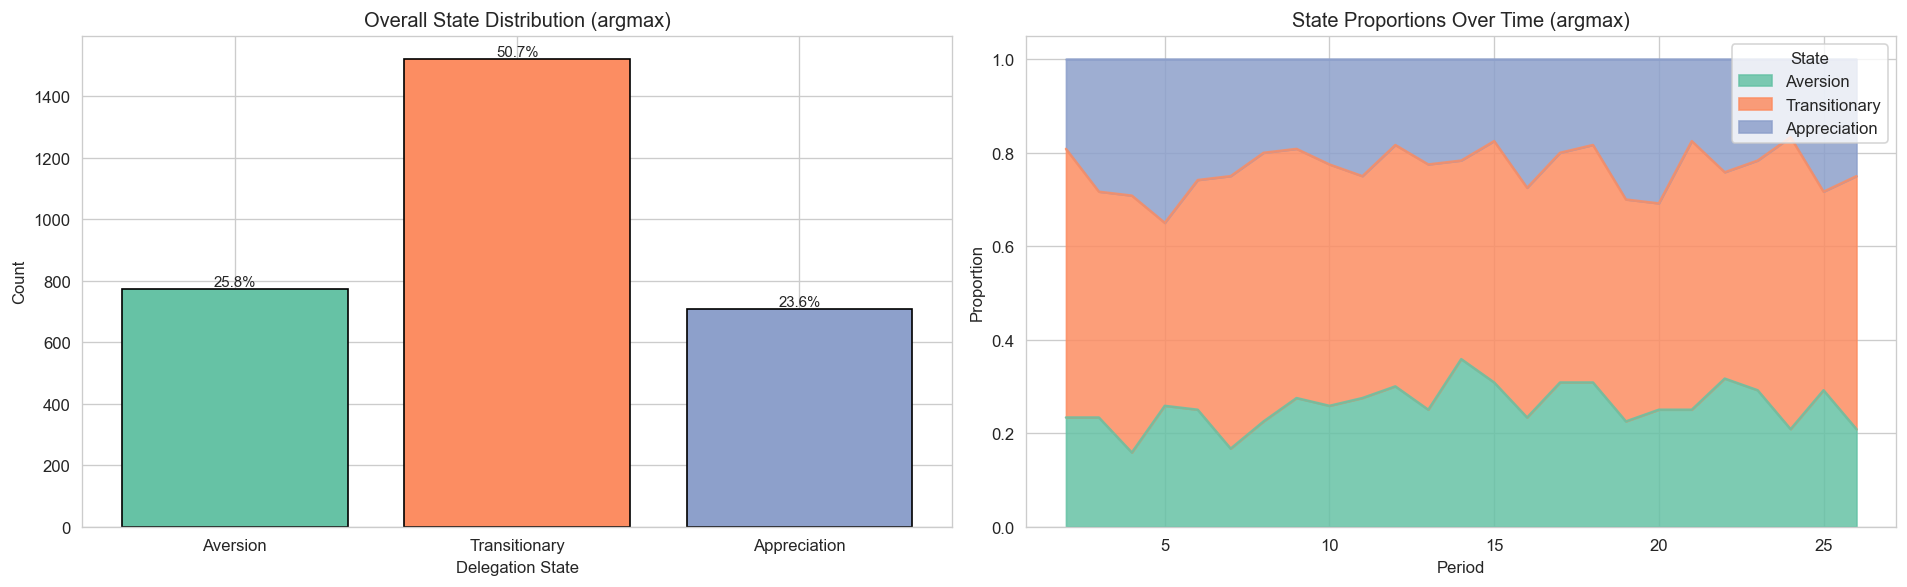

In [39]:
# ============================================================
# 4.2a. State distribution over time (3-state version)
#   - Uses your computed label_map + state_order_1idx
#   - Ensures plots show: Aversion → Transitionary → Appreciation
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."
assert "posteriors" in globals(), "posteriors not found. Run the posterior assignment cell first."

posteriors = posteriors.copy()

# Add/refresh labels using YOUR label_map
posteriors["state_label"] = posteriors["most_likely_state"].map(label_map)

# Order labels: Aversion → Transitionary → Appreciation
label_order = [label_map[s] for s in state_order_1idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ----------------------------
# 1) Overall distribution (bar chart)
# ----------------------------
freq_labeled = (
    posteriors["state_label"]
    .value_counts()
    .reindex(label_order)
    .fillna(0)
)

axes[0].bar(
    label_order,
    freq_labeled.values,
    color=sns.color_palette("Set2", len(label_order)),
    edgecolor="k"
)
axes[0].set_xlabel("Delegation State")
axes[0].set_ylabel("Count")
axes[0].set_title("Overall State Distribution (argmax)")

# Add percentage labels
total_n = float(freq_labeled.sum())
for i, val in enumerate(freq_labeled.values):
    pct = (val / total_n * 100.0) if total_n > 0 else 0.0
    axes[0].text(i, val, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

# ----------------------------
# 2) Proportion over time (stacked area)
# ----------------------------
pivot = (
    posteriors
    .groupby(["period_id", "state_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

pivot_pct.plot.area(
    ax=axes[1],
    stacked=True,
    alpha=0.85,
    color=sns.color_palette("Set2", len(label_order)),
)

axes[1].set_xlabel("Period")
axes[1].set_ylabel("Proportion")
axes[1].set_title("State Proportions Over Time (argmax)")
axes[1].legend(title="State", loc="upper right")

plt.tight_layout()
plt.show()


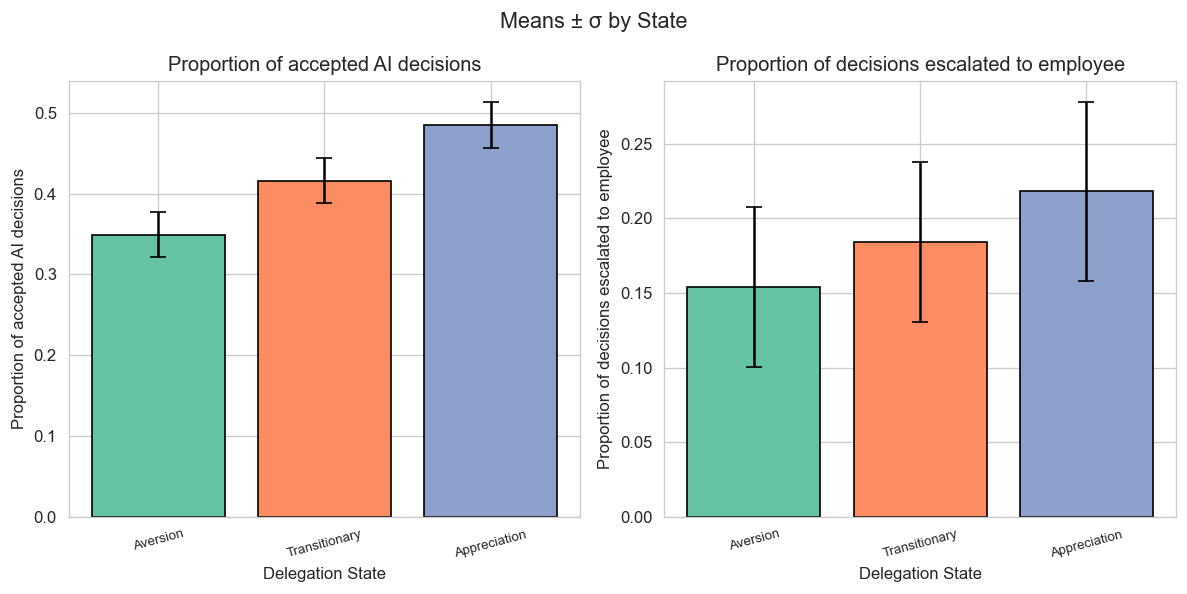

In [40]:

# ============================================================
# 4.2b. Emission means by state (original scale) — 3-state version
#   - Only the 2 independent emission dimensions
#     (AI Decision Authority Share, Escalation Share)
#   - override_rate omitted (= 1 − authority by construction)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

# Only independent dimensions
independent_dims = {
    0: ("ai_decision_authority_share", "Proportion of accepted AI decisions"),
    2: ("share_authority_esc", "Proportion of decisions escalated to employee"),
}

n_panels = len(independent_dims)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
axes = np.atleast_1d(axes)

state_order_1idx = list(state_order_1idx)
state_order_0idx = [s - 1 for s in state_order_1idx]
label_order = [label_map[s] for s in state_order_1idx]

palette = sns.color_palette("Set2", len(label_order))

for ax_idx, (d, (col, nice_name)) in enumerate(independent_dims.items()):
    ax = axes[ax_idx]

    vals = [mu_orig[s, d] for s in state_order_0idx]
    errs = [sigma_orig[s, d] for s in state_order_0idx]

    ax.bar(
        label_order,
        vals,
        yerr=errs,
        capsize=5,
        color=palette,
        edgecolor="k"
    )
    ax.set_xlabel("Delegation State")
    ax.set_ylabel(nice_name)
    ax.set_title(nice_name)
    ax.tick_params(axis="x", labelsize=8, rotation=15)

plt.suptitle("Means ± σ by State", fontsize=13)
plt.tight_layout()
plt.show()


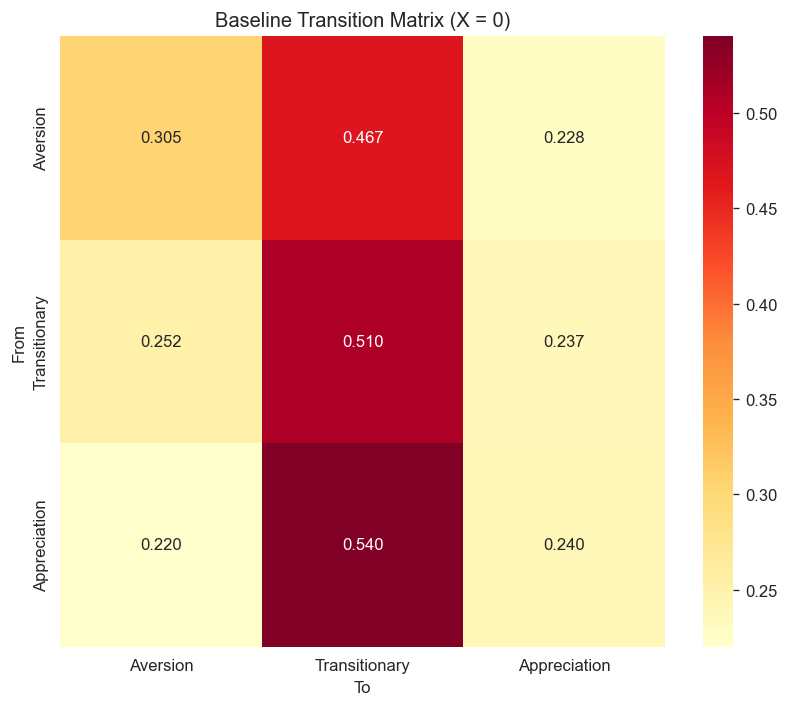


Transition probabilities (rows sum to 1):
  From Aversion: [0.305 0.467 0.228]
  From Transitionary: [0.252 0.510 0.237]
  From Appreciation: [0.220 0.540 0.240]


In [41]:
# ============================================================
# 4.2c. Transition matrix heatmap (baseline, at X=0) — 3-state version
#   - Uses your computed label_map + state_order_1idx
#   - Displays in order: Aversion → Transitionary → Appreciation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

# ---- Baseline transition matrix at X=0 ----
Q_base = np.zeros((best_J, best_J))
for j in range(best_J):
    logits = best_model.alpha[j]
    Q_base[j] = softmax(logits)

# ---- Display order: Aversion → Transitionary → Appreciation ----
state_display_order = [s - 1 for s in state_order_1idx]
label_order = [label_map[s] for s in state_order_1idx]

Q_base_ordered = Q_base[np.ix_(state_display_order, state_display_order)]

# ---- Heatmap ----
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    Q_base_ordered,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    xticklabels=label_order,
    yticklabels=label_order,
    ax=ax
)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_title("Baseline Transition Matrix (X = 0)")
plt.tight_layout()
plt.show()

# ---- Print formatted rows ----
print("\nTransition probabilities (rows sum to 1):")
for i, from_label in enumerate(label_order):
    from_state = state_display_order[i]
    probs = " ".join(f"{Q_base[from_state, state_display_order[j]]:.3f}" for j in range(best_J))
    print(f"  From {from_label}: [{probs}]")


<a id="5-kpi-driven-transition-dynamics"></a>
## 5. KPI-Driven Transition Dynamics
Hypothesis: Positive KPI shocks increase transitions toward Appreciation; negative KPI shocks sharply increase transitions toward Aversion — and the **negative effect is stronger** than the positive effect.

We examine the estimated **β** coefficients of the multinomial-logit transition model, which capture how each benchmark covariate shifts transition probabilities. We also simulate transition matrices at ±1 SD of each KPI covariate.

Detected transition covariates in model: P = 7
Transition covariate labels used: ['within_unit_temporal_benchmark', 'horizontal_peer_benchmark', 'within_unit_ai_trajectory_benchmark', 'threshold_benchmark', 'transparency_moderator', 'x_cov_5', 'x_cov_6']

═══  Transition Covariate Coefficients (β)  ═══


── β coefficients (scaled X): within_unit_temporal_benchmark ──


To,Aversion,Transitionary,Appreciation
From,,,
Aversion,-0.0135,0.2098,-0.1957
Transitionary,0.0639,0.0579,-0.1213
Appreciation,0.0742,-0.0850,0.0121



── β coefficients (scaled X): horizontal_peer_benchmark ──


To,Aversion,Transitionary,Appreciation
From,,,
Aversion,-0.1280,0.1654,-0.0381
Transitionary,0.0016,0.0166,-0.0186
Appreciation,-0.0385,0.0954,-0.0563



── β coefficients (scaled X): within_unit_ai_trajectory_benchmark ──


To,Aversion,Transitionary,Appreciation
From,,,
Aversion,0.1210,-0.3125,0.1911
Transitionary,0.0397,-0.1140,0.0746
Appreciation,-0.1411,0.1969,-0.0555



═══  Simulated Transition Matrices Under Shocks (±1 SD, scaled X)  ═══



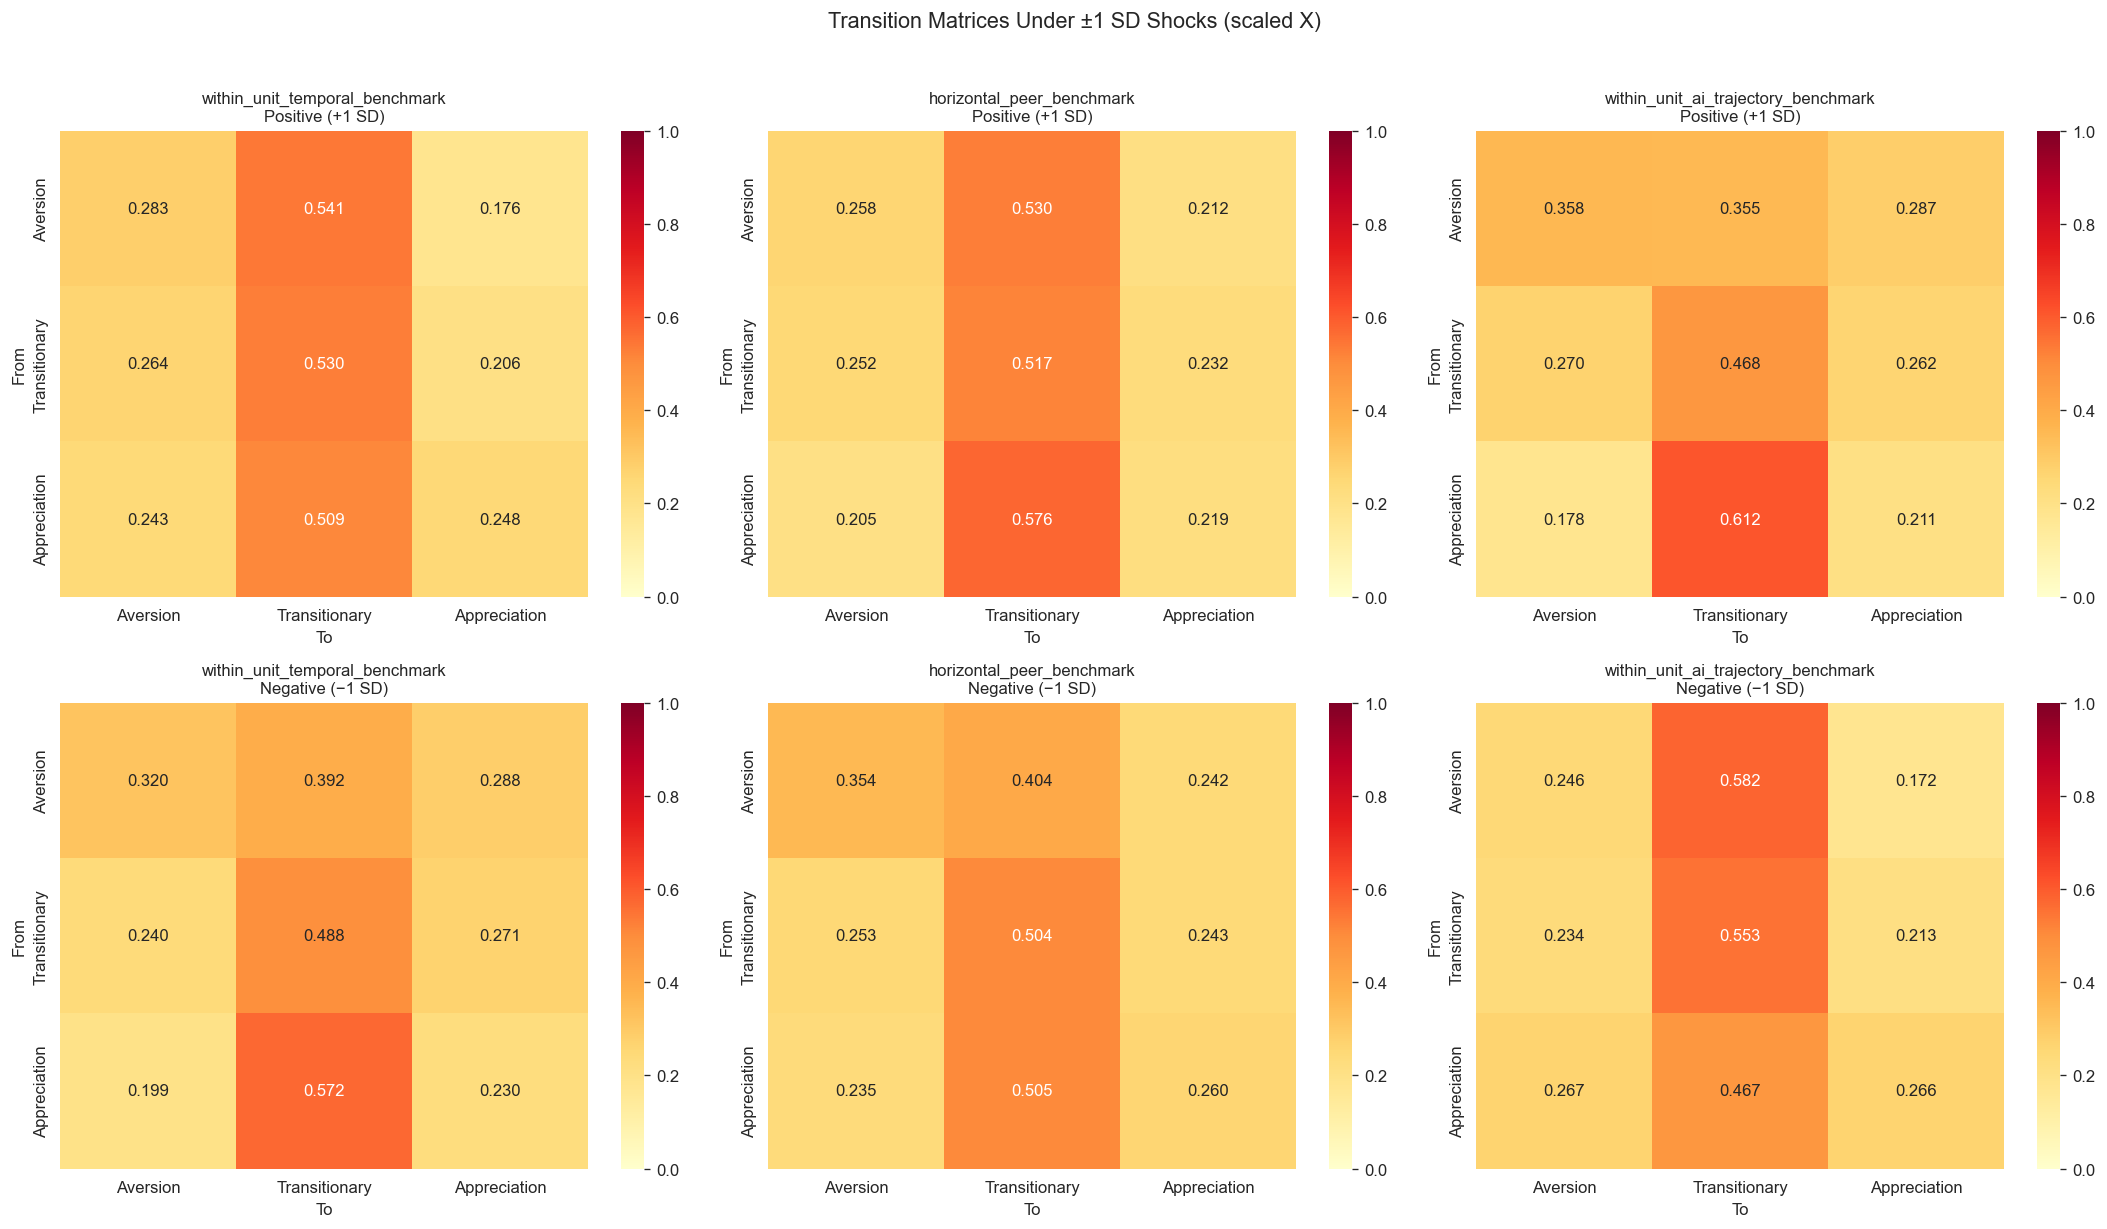


═══  Asymmetry: Avg ΔP(→Aversion) vs Avg ΔP(→Appreciation)  ═══



,Covariate,Shock,Avg ΔP(→Aversion),Avg ΔP(→Transitionary),Avg ΔP(→Appreciation)
0,within_unit_temporal_benchmark,Positive (+1SD),0.0040,0.0208,-0.0247
1,within_unit_temporal_benchmark,Negative (−1SD),-0.0062,-0.0218,0.0280
2,horizontal_peer_benchmark,Positive (+1SD),-0.0208,0.0350,-0.0142
3,horizontal_peer_benchmark,Negative (−1SD),0.0215,-0.0349,0.0134
4,within_unit_ai_trajectory_benchmark,Positive (+1SD),0.0092,-0.0277,0.0185
5,within_unit_ai_trajectory_benchmark,Negative (−1SD),-0.0100,0.0280,-0.0180



✓ Result 5.1.2: Transition coefficients and shock simulations for 3 states.


In [42]:
# ============================================================
# 5.1.2  Asymmetric KPI-Driven State Transitions (3-state version)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

assert "label_map" in globals(), "label_map not found. Run STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run STATE LABELING cell first."

# Display order: Aversion → Transitionary → Appreciation
state_display_order_0 = [s - 1 for s in state_order_1idx]
label_order = [label_map[s] for s in state_order_1idx]

aversion_idx0      = state_display_order_0[0]
transitionary_idx0 = state_display_order_0[1]
appreciation_idx0  = state_display_order_0[2]

# ------------------------------------------------------------
# 0) Infer P from the fitted model
# ------------------------------------------------------------
beta = best_model.beta
assert beta.ndim == 3, f"Expected beta to be 3D (J,J,P). Got {beta.shape}."
P_model = beta.shape[2]
print(f"Detected transition covariates in model: P = {P_model}")

transition_cols_full = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "within_unit_ai_trajectory_benchmark",
    "threshold_benchmark",
    "transparency_moderator",
]

if P_model <= len(transition_cols_full):
    transition_cols = transition_cols_full[:P_model]
else:
    transition_cols = transition_cols_full + [f"x_cov_{i}" for i in range(len(transition_cols_full), P_model)]

print("Transition covariate labels used:", transition_cols)

# Unscale if scaler matches P
if hasattr(data, "x_scaler") and hasattr(data.x_scaler, "scale_") and len(data.x_scaler.scale_) == P_model:
    beta_orig = beta / data.x_scaler.scale_[None, None, :]
    have_unscale = True
else:
    beta_orig = beta.copy()
    have_unscale = False
    print("⚠️ x_scaler.scale_ not available or dimension mismatch → skipping unscale.")

# ------------------------------------------------------------
# a) Beta coefficient table
# ------------------------------------------------------------
print("\n═══  Transition Covariate Coefficients (β)  ═══\n")
beta_rows = []
for p_idx, cov in enumerate(transition_cols):
    for from_pos, from_label in enumerate(label_order):
        i0 = state_display_order_0[from_pos]
        for to_pos, to_label in enumerate(label_order):
            j0 = state_display_order_0[to_pos]
            row = {
                "Covariate": cov,
                "From": from_label,
                "To": to_label,
                "β (scaled)": round(float(beta[i0, j0, p_idx]), 4),
            }
            if have_unscale:
                row["β (orig units)"] = round(float(beta_orig[i0, j0, p_idx]), 4)
            beta_rows.append(row)

beta_df = pd.DataFrame(beta_rows)

# Print pivots for up to 3 covariates
for cov in transition_cols[:3]:
    sub = beta_df[beta_df["Covariate"] == cov].pivot(index="From", columns="To", values="β (scaled)")
    print(f"\n── β coefficients (scaled X): {cov} ──")
    display(sub.reindex(index=label_order, columns=label_order).round(4))

# ------------------------------------------------------------
# b) Simulated transition matrices at ±1 SD of KPI (scaled space)
# ------------------------------------------------------------
print("\n═══  Simulated Transition Matrices Under Shocks (±1 SD, scaled X)  ═══\n")

kpi_covariates = [(transition_cols[i], i) for i in range(min(3, P_model))]
n_cov = len(kpi_covariates)

fig, axes = plt.subplots(2, n_cov, figsize=(6*n_cov, 10), squeeze=False)

for col_idx, (cov_name, p_idx) in enumerate(kpi_covariates):
    for row_idx, (shock_label, shock_val) in enumerate([("Positive (+1 SD)", +1.0),
                                                         ("Negative (−1 SD)", -1.0)]):
        x_vec = np.zeros(P_model)
        x_vec[p_idx] = shock_val

        Q_shock = np.zeros((best_J, best_J))
        for i0 in range(best_J):
            logits = best_model.alpha[i0] + best_model.beta[i0] @ x_vec
            Q_shock[i0] = softmax(logits)

        Q_shock_ordered = Q_shock[np.ix_(state_display_order_0, state_display_order_0)]

        ax = axes[row_idx, col_idx]
        sns.heatmap(
            Q_shock_ordered,
            annot=True,
            fmt=".3f",
            cmap="YlOrRd",
            xticklabels=label_order,
            yticklabels=label_order,
            ax=ax,
            vmin=0,
            vmax=1.0
        )
        ax.set_title(f"{cov_name}\n{shock_label}", fontsize=10)
        ax.set_xlabel("To")
        ax.set_ylabel("From")

plt.suptitle("Transition Matrices Under ±1 SD Shocks (scaled X)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# c) Asymmetry quantification
# ------------------------------------------------------------
print("\n═══  Asymmetry: Avg ΔP(→Aversion) vs Avg ΔP(→Appreciation)  ═══\n")

asym_rows = []
for cov_name, p_idx in kpi_covariates:
    for shock_label, shock_val in [("Positive (+1SD)", +1.0), ("Negative (−1SD)", -1.0)]:
        x_vec = np.zeros(P_model)
        x_vec[p_idx] = shock_val

        d_to_av, d_to_trans, d_to_app = [], [], []
        for i0 in range(best_J):
            p_base = softmax(best_model.alpha[i0])
            p_shock = softmax(best_model.alpha[i0] + best_model.beta[i0] @ x_vec)

            d_to_av.append(p_shock[aversion_idx0] - p_base[aversion_idx0])
            d_to_trans.append(p_shock[transitionary_idx0] - p_base[transitionary_idx0])
            d_to_app.append(p_shock[appreciation_idx0] - p_base[appreciation_idx0])

        asym_rows.append({
            "Covariate": cov_name,
            "Shock": shock_label,
            "Avg ΔP(→Aversion)": round(float(np.mean(d_to_av)), 4),
            "Avg ΔP(→Transitionary)": round(float(np.mean(d_to_trans)), 4),
            "Avg ΔP(→Appreciation)": round(float(np.mean(d_to_app)), 4),
        })

asym_df = pd.DataFrame(asym_rows)
display(asym_df)

print("\n✓ Result 5.1.2: Transition coefficients and shock simulations for 3 states.")


<a id="7-strategic-control-retention-under-high-task-stakes"></a>
## 7. Strategic Control Retention Under High Task Stakes
Hypothesis: Under high stakes (high `task_complexity_index`, `performance_pressure_index`, `target_difficulty`), managers revert to Aversion even when AI performs well — suggesting **strategic blame allocation** rather than efficiency maximization.

We examine:
1. **Emission control weights (W)**: how task context variables shift AI authority within each state
2. **Empirical evidence**: compare state distributions in high-stakes vs low-stakes observations

---
# Part III — Theoretical and Task-Level Implications

<a id="8-delegation-as-dynamic-learning-process"></a>
## 8. Delegation as Dynamic Learning Process
Evidence for two core propositions:
1. **Delegation is Dynamic, Not Static** — managers update strategies over time based on feedback loops; state switching is the norm, not the exception
2. **Algorithm Aversion/Appreciation Are States, Not Traits** — willingness to delegate evolves through learning; the same manager can visit all three delegation states (Aversion, Transitionary, and Appreciation) over the observation window

<a id="9-authority-as-strategic-and-legitimacy-mechanism"></a>
## 9. Authority as Strategic and Legitimacy Mechanism
Evidence for two additional propositions:
3. **Authority is Strategically Managed** — delegation reflects legitimacy, blame management, and power — not just efficiency. Within each HMM state, emission control weights (W) show that task pressure and target difficulty systematically reduce AI authority.
4. **Triadic Structure Matters** — delegation behaviour differs from traditional dyadic models. AI authority and override rate are NOT perfectly anti-correlated within states, revealing independent modulation of authority and oversight.

In [50]:

# ── 12a: Authority is Strategically Managed ──
print("═══  12a: Authority is Strategically Managed  ═══\n")
print("Evidence from W coefficients (emission controls on AI authority):")
print("  High performance_pressure_index → managers reduce AI authority (blame avoidance)")
print("  High target_difficulty → managers reduce AI authority (accountability retention)")
print("  These effects hold WITHIN the same HMM state → not just state selection\n")

label_order = [label_map[s] for s in state_order_1idx]
state_display_order = [s - 1 for s in state_order_1idx]

# Ensure control_cols is available globally (mirrors load_sequences definition)
control_cols = [
    "task_complexity_index",
    "demand_volatility",
    "supply_disruption_count",
    "forecast_accuracy_mape",
    "decision_latency_avg",
    "target_difficulty",
    "performance_pressure_index",
    "recent_negative_shock",
]

emission_cols_local = ["ai_decision_authority_share", "override_rate", "share_authority_esc"]

# Always build merged fresh from in-memory data (avoids duplicate-column issues)
_dfs = []
for i, (mid, periods_i, Y_i, Z_i) in enumerate(zip(data.ids, data.periods, data.Y, data.Z)):
    Y_orig = data.y_scaler.inverse_transform(Y_i)
    Z_orig = data.z_scaler.inverse_transform(Z_i)
    for t in range(len(periods_i)):
        row = {"manager_id": mid, "period_id": int(periods_i[t])}
        for d, col in enumerate(emission_cols_local):
            row[col] = float(Y_orig[t, d])
        for k, col in enumerate(control_cols):
            row[col] = float(Z_orig[t, k])
        _dfs.append(row)
_panel_df = pd.DataFrame(_dfs)

# Use only clean columns from posteriors to avoid duplicates
_post_clean = posteriors[["manager_id", "period_id", "most_likely_state",
                           "most_likely_label"]].copy()
_post_clean = _post_clean.rename(columns={"most_likely_label": "state_label"})
merged = _post_clean.merge(_panel_df, on=["manager_id", "period_id"], how="left")
print(f"  merged built: {merged.shape[0]:,} rows, {merged.shape[1]} columns")

# Stakes-related control variables (subset of control_cols)
stakes_controls = [
    "performance_pressure_index",
    "target_difficulty",
    "task_complexity_index",
    "recent_negative_shock",
]

available_stakes = [c for c in stakes_controls if c in control_cols]
if len(available_stakes) > 0:
    stakes_W = pd.DataFrame({
        label: [float(best_model.W[state_display_order[i], 0, control_cols.index(c)]) for c in available_stakes]
        for i, label in enumerate(label_order)
    }, index=available_stakes)
    print("W coefficients (AI authority share) for stakes controls:")
    display(stakes_W.round(4))
else:
    print("⚠️ No stakes-related controls available in model (K too small).")

# Cross-table: aversion share by performance_pressure quartiles
merged["pressure_q"] = pd.qcut(merged["performance_pressure_index"], 4,
                                labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])
aversion_label = label_map[state_order_1idx[0]]
merged["_is_aversion"] = (merged["state_label"] == aversion_label).astype(float)
aversion_rate_by_pressure = (
    merged.groupby("pressure_q", observed=False)["_is_aversion"].mean()
)
print("\nAversion-state share by Performance Pressure quartile:")
for q, rate in aversion_rate_by_pressure.items():
    print(f"  {q}: {rate:.3f}")

# ── 12b: Triadic Structure Matters ──
print("\n═══  12b: Triadic Structure Matters  ═══\n")
print("Note: override_rate = 1 − ai_decision_authority_share by construction,")
print("so these two emissions are algebraically redundant (ρ = −1.000).")
print("The effective model therefore has D=2 independent emission dimensions.\n")

print("The triadic structure is captured by the THIRD emission dimension:")
print("  • Escalation share (share_authority_esc) — the proportion of decisions")
print("    routed to the employee/team layer rather than resolved in the")
print("    manager ↔ AI dyad.\n")

print("── Evidence: Escalation share varies independently across states ──\n")
esc_mean = np.array([mu_orig[s - 1, 2] for s in state_order_1idx])
ai_mean  = np.array([mu_orig[s - 1, 0] for s in state_order_1idx])
esc_se   = np.array([sigma_orig[s - 1, 2] for s in state_order_1idx])

for i, label in enumerate(label_order):
    print(f"  {label:15s}: AI authority = {ai_mean[i]:.3f},  "
          f"Escalation share = {esc_mean[i]:.3f} ± {esc_se[i]:.3f}")

from scipy.stats import spearmanr
if "ai_decision_authority_share" in merged.columns and "share_authority_esc" in merged.columns:
    rho, p_val = spearmanr(merged["ai_decision_authority_share"],
                           merged["share_authority_esc"])
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "n.s."))
    print(f"\n  Spearman ρ(AI authority, escalation share) = {rho:+.3f}  (p = {p_val:.4f}) {sig}")
    print(f"\n  → ρ ≠ −1: escalation is NOT a mirror of authority allocation.")
    print(f"    Managers independently modulate how much they route upward/laterally")
    print(f"    to employees, beyond their binary accept/override stance toward AI.\n")
else:
    print("\n  ⚠️ Cannot compute correlation — columns missing from merged data.")

print("Implication:")
print("  A dyadic model (manager ↔ AI) captures only the authority–override")
print("  dimension. The triadic model adds the employee escalation channel,")
print("  revealing that managers use a THREE-WAY delegation strategy:")
print("    (1) Delegate authority to AI  (ai_decision_authority_share)")
print("    (2) Retain authority / override AI  (= 1 − authority share)")
print("    (3) Route decisions to employees  (share_authority_esc)")
print("  These three channels move partly independently across states.")

print("\n" + "═" * 60)
print("✓ §12 complete: Authority management is strategic (blame/legitimacy)")
print("  and the triadic structure adds an independent escalation dimension")
print("  beyond what dyadic manager ↔ AI models can capture.")
print("═" * 60)


═══  12a: Authority is Strategically Managed  ═══

Evidence from W coefficients (emission controls on AI authority):
  High performance_pressure_index → managers reduce AI authority (blame avoidance)
  High target_difficulty → managers reduce AI authority (accountability retention)
  These effects hold WITHIN the same HMM state → not just state selection

  merged built: 3,000 rows, 15 columns
W coefficients (AI authority share) for stakes controls:


,Aversion,Transitionary,Appreciation
performance_pressure_index,-0.0047,0.0045,0.0055
target_difficulty,0.0052,-0.0080,-0.0114
task_complexity_index,0.7752,0.7846,0.7904
recent_negative_shock,-0.0709,-0.0554,-0.0401



Aversion-state share by Performance Pressure quartile:
  Q1 (low): 0.251
  Q2: 0.233
  Q3: 0.292
  Q4 (high): 0.255

═══  12b: Triadic Structure Matters  ═══

Note: override_rate = 1 − ai_decision_authority_share by construction,
so these two emissions are algebraically redundant (ρ = −1.000).
The effective model therefore has D=2 independent emission dimensions.

The triadic structure is captured by the THIRD emission dimension:
  • Escalation share (share_authority_esc) — the proportion of decisions
    routed to the employee/team layer rather than resolved in the
    manager ↔ AI dyad.

── Evidence: Escalation share varies independently across states ──

  Aversion       : AI authority = 0.349,  Escalation share = 0.154 ± 0.054
  Transitionary  : AI authority = 0.416,  Escalation share = 0.184 ± 0.054
  Appreciation   : AI authority = 0.485,  Escalation share = 0.218 ± 0.060

  Spearman ρ(AI authority, escalation share) = -0.371  (p = 0.0000) ***

  → ρ ≠ −1: escalation is NOT a mi

<a id="10-triadic-delegation-flows-authority-vs-execution"></a>
## 10. Triadic Delegation Flows: Authority vs Execution

═══  Loading Task-Level Episode Tables  ═══

decision_episode : 144,411 tasks  (19 cols)
execution_episode: 144,411 tasks  (10 cols)

Merged task table: 144,411 rows

═══  Per Manager-Period Authority & Execution Counts  ═══

manager_id  period_id  n_tasks_total  share_authority_ai  share_authority_mgr  share_authority_esc  share_exec_ai  share_exec_employee  share_exec_joint
     M0001          1             57            0.438596             0.456140             0.105263       0.403509             0.298246          0.298246
     M0001          2             47            0.595745             0.170213             0.234043       0.553191             0.212766          0.234043
     M0001          3             35            0.542857             0.342857             0.114286       0.457143             0.400000          0.142857
     M0001          4             38            0.605263             0.184211             0.210526       0.552632             0.210526          0.236842
     M000

,AI Accepted\n(No Override),Manager Override\n(Modify/Reject),Escalated\n(Team-Involved)
state_label,,,
Aversion,0.2796,0.5654,0.1550
Transitionary,0.3493,0.4666,0.1841
Appreciation,0.4137,0.3695,0.2167



═══  Execution Flow Distribution by HMM State  ═══



,AI-Executed\n(Autonomous),Employee-Executed\n(Human Only),Joint Execution\n(AI + Employee)
state_label,,,
Aversion,0.2780,0.4377,0.2843
Transitionary,0.3285,0.3905,0.2809
Appreciation,0.3802,0.3470,0.2727


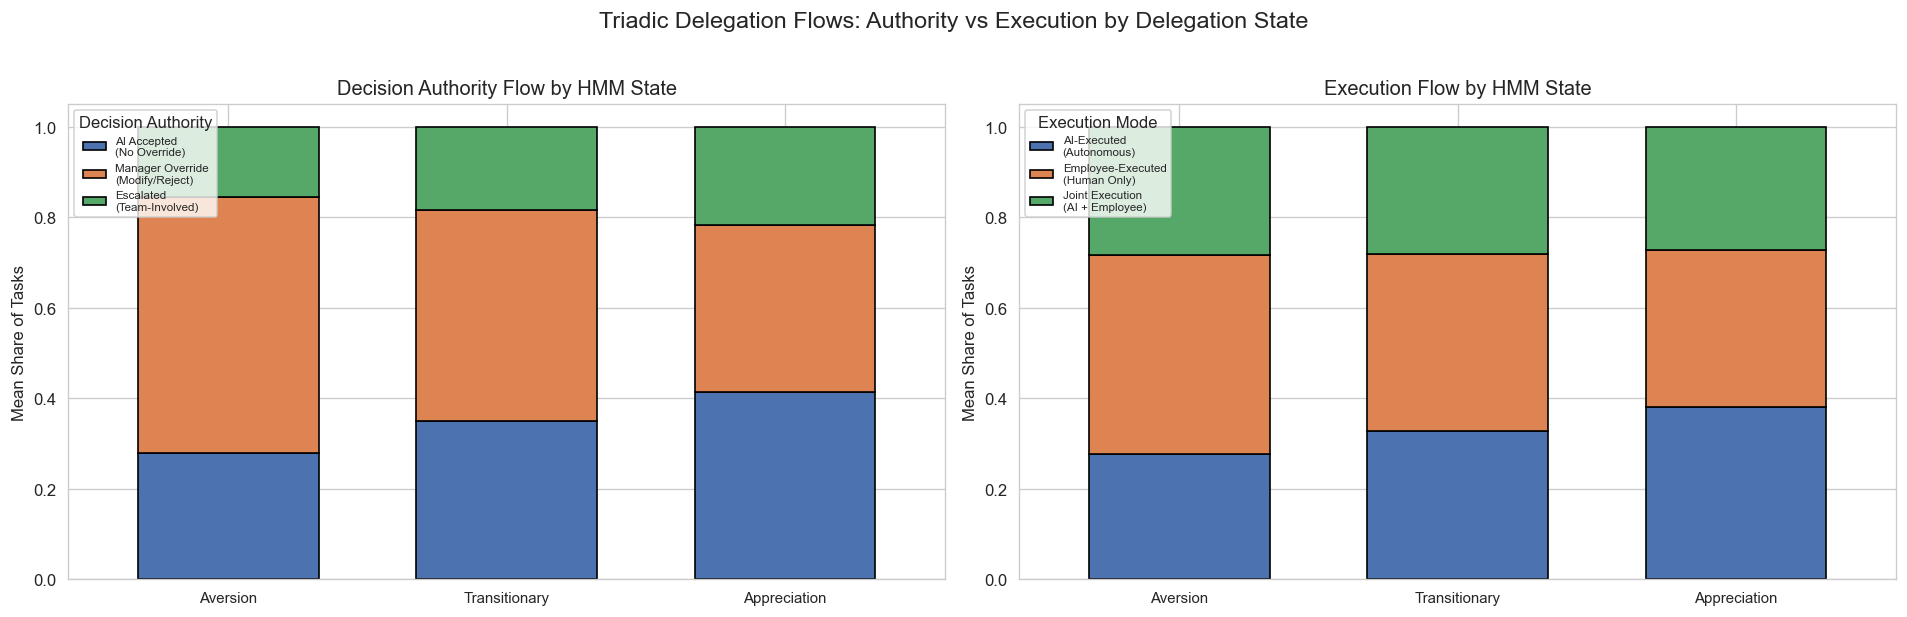


═══  Combined Authority × Execution Cross-Table by State  ═══

── Aversion ── (34,723 tasks)


,AI-Executed,Employee-Executed,Joint
Decision Authority,,,
AI Accepted (No Override),0.6496,0.1000,0.2504
Manager Override,0.1003,0.5987,0.3009
Escalated (Team-Involved),0.2564,0.4578,0.2858



── Transitionary ── (70,821 tasks)


,AI-Executed,Employee-Executed,Joint
Decision Authority,,,
AI Accepted (No Override),0.6485,0.0997,0.2518
Manager Override,0.0992,0.5992,0.3016
Escalated (Team-Involved),0.3023,0.4156,0.2821



── Appreciation ── (31,755 tasks)


,AI-Executed,Employee-Executed,Joint
Decision Authority,,,
AI Accepted (No Override),0.6489,0.1007,0.2504
Manager Override,0.1031,0.6026,0.2943
Escalated (Team-Involved),0.3382,0.3814,0.2804



═══  Statistical Test: Authority AI Share Across States  ═══

Kruskal-Wallis H = 103.43, p = 0.000000
  → Authority flows differ significantly across HMM states (p < 0.05)

═══  Chi-Squared: Majority-AI-Authority × HMM State  ═══

χ² = 110.84, p = 0.000000, dof = 2

═══  Employee Override During Execution by State  ═══



,Mean Override Rate,Std,Count
state_label,,,
Aversion,0.0368,0.0308,773
Transitionary,0.0387,0.0294,1520
Appreciation,0.0416,0.0308,707


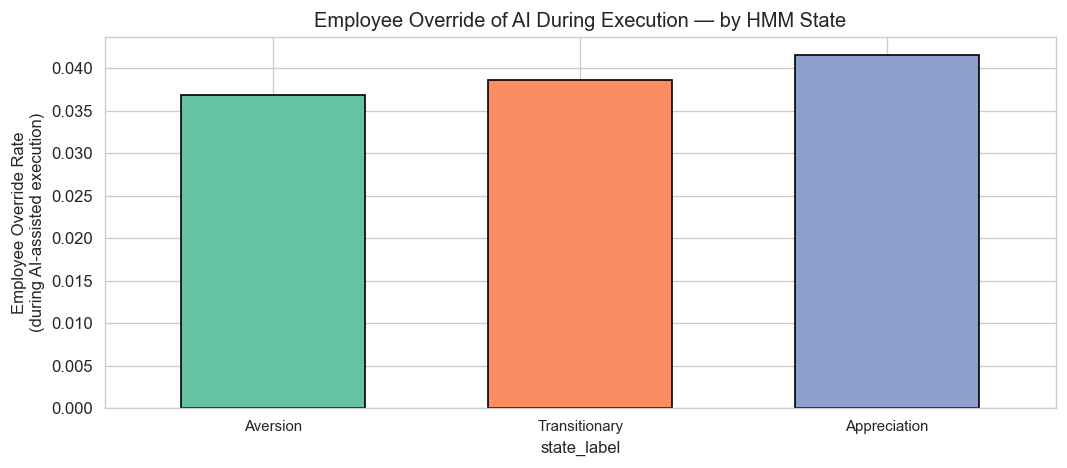


════════════════════════════════════════════════════════════
✓ Section 5.3 complete: Triadic delegation flows confirm that
  authority (who decides) and execution (who acts) are distinct
  dimensions that vary systematically across all three delegation states.
════════════════════════════════════════════════════════════


In [51]:
# ============================================================
# 5.3  Triadic Delegation Flows — Task-Level Evidence (3-state)
# ============================================================

print("═══  Loading Task-Level Episode Tables  ═══\n")

# ── 1. Load decision_episode ──
dec_ep = pd.read_excel(DATA_PATH, sheet_name="decision_episode")
print(f"decision_episode : {dec_ep.shape[0]:,} tasks  ({dec_ep.shape[1]} cols)")

# ── 2. Load execution_episode ──
exec_ep = pd.read_excel(DATA_PATH, sheet_name="execution_episode", engine="openpyxl")
print(f"execution_episode: {exec_ep.shape[0]:,} tasks  ({exec_ep.shape[1]} cols)")

# ── 3. Create per-task AUTHORITY_ACTOR label ──
def map_authority(row):
    if row["escalation_flag"] == 1:
        return "Escalated (Team-Involved)"
    elif row["manager_action"] == "accept":
        return "AI Accepted (No Override)"
    else:
        return "Manager Override"

dec_ep["authority_actor"] = dec_ep.apply(map_authority, axis=1)

# ── 4. Merge execution_mode onto decision_episode via episode_id ──
exec_mode = exec_ep[["episode_id", "execution_mode", "employee_override_during_execution"]].copy()
exec_mode_agg = (exec_mode
    .groupby("episode_id")
    .agg(execution_mode=("execution_mode", lambda x: x.mode().iloc[0]),
         any_emp_override=("employee_override_during_execution", "max"))
    .reset_index())

tasks = dec_ep.merge(exec_mode_agg, on="episode_id", how="left")
print(f"\nMerged task table: {tasks.shape[0]:,} rows")

# ── 5. Aggregate counts per manager-period ──
print("\n═══  Per Manager-Period Authority & Execution Counts  ═══\n")

auth_counts = (tasks
    .groupby(["manager_id", "period_id", "authority_actor"])
    .size()
    .unstack(fill_value=0)
    .reset_index())

for c in ["AI Accepted (No Override)", "Manager Override", "Escalated (Team-Involved)"]:
    if c not in auth_counts.columns:
        auth_counts[c] = 0

auth_counts.rename(columns={"AI Accepted (No Override)": "n_authority_ai",
                             "Manager Override": "n_authority_mgr",
                             "Escalated (Team-Involved)": "n_authority_escalated"}, inplace=True)
auth_counts["n_tasks_total"] = (auth_counts["n_authority_ai"]
                                + auth_counts["n_authority_mgr"]
                                + auth_counts["n_authority_escalated"])

exec_counts = (tasks
    .groupby(["manager_id", "period_id", "execution_mode"])
    .size()
    .unstack(fill_value=0)
    .reset_index())
exec_counts.columns.name = None

for c in ["ai", "human", "joint"]:
    if c not in exec_counts.columns:
        exec_counts[c] = 0

exec_counts.rename(columns={"ai": "n_exec_ai",
                             "human": "n_exec_employee",
                             "joint": "n_exec_joint"}, inplace=True)

task_agg = auth_counts.merge(exec_counts, on=["manager_id", "period_id"], how="outer").fillna(0)

task_agg["share_authority_ai"]  = task_agg["n_authority_ai"]  / task_agg["n_tasks_total"]
task_agg["share_authority_mgr"] = task_agg["n_authority_mgr"] / task_agg["n_tasks_total"]
task_agg["share_authority_esc"] = task_agg["n_authority_escalated"] / task_agg["n_tasks_total"]

exec_total = task_agg["n_exec_ai"] + task_agg["n_exec_employee"] + task_agg["n_exec_joint"]
task_agg["share_exec_ai"]       = task_agg["n_exec_ai"]       / exec_total
task_agg["share_exec_employee"] = task_agg["n_exec_employee"] / exec_total
task_agg["share_exec_joint"]    = task_agg["n_exec_joint"]    / exec_total

print(task_agg[["manager_id", "period_id", "n_tasks_total",
                "share_authority_ai", "share_authority_mgr", "share_authority_esc",
                "share_exec_ai", "share_exec_employee", "share_exec_joint"]].head(8).to_string(index=False))

# ── 6. Link to HMM states ──
task_state = task_agg.merge(
    posteriors[["manager_id", "period_id", "most_likely_state"]],
    on=["manager_id", "period_id"], how="inner")

task_state["state_label"] = task_state["most_likely_state"].map(label_map)

print(f"\nTask-State merged: {task_state.shape[0]:,} manager-period obs with HMM state labels")

# ── 7. Authority Flow by HMM State ──
print("\n═══  Authority Flow Distribution by HMM State  ═══\n")

label_order = [label_map[s] for s in state_order_1idx]
auth_by_state = task_state.groupby("state_label")[
    ["share_authority_ai", "share_authority_mgr", "share_authority_esc"]
].mean().reindex(label_order)
auth_by_state.columns = ["AI Accepted\n(No Override)",
                         "Manager Override\n(Modify/Reject)",
                         "Escalated\n(Team-Involved)"]
display(auth_by_state.round(4))

# ── 8. Execution Flow by HMM State ──
print("\n═══  Execution Flow Distribution by HMM State  ═══\n")

exec_by_state = task_state.groupby("state_label")[
    ["share_exec_ai", "share_exec_employee", "share_exec_joint"]
].mean().reindex(label_order)
exec_by_state.columns = ["AI-Executed\n(Autonomous)",
                         "Employee-Executed\n(Human Only)",
                         "Joint Execution\n(AI + Employee)"]
display(exec_by_state.round(4))

# ── 9. Visualisation: Stacked Bar Charts ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

auth_by_state.plot(kind="bar", stacked=True, ax=axes[0],
                   color=["#4C72B0", "#DD8452", "#55A868"],
                   edgecolor="k", width=0.65)
axes[0].set_title("Decision Authority Flow by HMM State", fontsize=12)
axes[0].set_ylabel("Mean Share of Tasks")
axes[0].set_xlabel("")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha="center", fontsize=9)
axes[0].legend(title="Decision Authority", fontsize=7, loc="upper left")
axes[0].set_ylim(0, 1.05)

exec_by_state.plot(kind="bar", stacked=True, ax=axes[1],
                   color=["#4C72B0", "#DD8452", "#55A868"],
                   edgecolor="k", width=0.65)
axes[1].set_title("Execution Flow by HMM State", fontsize=12)
axes[1].set_ylabel("Mean Share of Tasks")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha="center", fontsize=9)
axes[1].legend(title="Execution Mode", fontsize=7, loc="upper left")
axes[1].set_ylim(0, 1.05)

plt.suptitle("Triadic Delegation Flows: Authority vs Execution by Delegation State",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── 10. Sankey-style summary table ──
print("\n═══  Combined Authority × Execution Cross-Table by State  ═══\n")

tasks_with_state = tasks.merge(
    posteriors[["manager_id", "period_id", "most_likely_state"]],
    on=["manager_id", "period_id"], how="inner")
tasks_with_state["state_label"] = tasks_with_state["most_likely_state"].map(label_map)

for sl in label_order:
    sub_tasks = tasks_with_state[tasks_with_state["state_label"] == sl]
    if sub_tasks.shape[0] == 0:
        continue
    cross = pd.crosstab(sub_tasks["authority_actor"], sub_tasks["execution_mode"],
                        normalize="index")
    cross.index.name = "Decision Authority"
    cross.columns.name = "Execution Mode"
    cross = cross.reindex(
        index=["AI Accepted (No Override)", "Manager Override", "Escalated (Team-Involved)"],
        columns=["ai", "human", "joint"]).fillna(0)
    cross.columns = ["AI-Executed", "Employee-Executed", "Joint"]
    print(f"── {sl} ── ({sub_tasks.shape[0]:,} tasks)")
    display(cross.round(4))
    print()

# ── 11. Statistical test: are authority flows different across states? ──
print("═══  Statistical Test: Authority AI Share Across States  ═══\n")
from scipy.stats import chi2_contingency, kruskal

groups_auth = [g["share_authority_ai"].values
               for _, g in task_state.groupby("state_label")]
if len(groups_auth) == 3:
    kw_h, kw_p = kruskal(*groups_auth)
    print(f"Kruskal-Wallis H = {kw_h:.2f}, p = {kw_p:.6f}")
    if kw_p < 0.05:
        print("  → Authority flows differ significantly across HMM states (p < 0.05)")
    else:
        print("  → Not significant at α=0.05")
elif len(groups_auth) == 2:
    from scipy.stats import mannwhitneyu as mwu_test
    u_stat_auth, p_auth = mwu_test(groups_auth[0], groups_auth[1], alternative="two-sided")
    print(f"U = {u_stat_auth:.2f}, p = {p_auth:.6f}")
else:
    kw_h, kw_p = kruskal(*groups_auth)
    print(f"Kruskal-Wallis H = {kw_h:.2f}, p = {kw_p:.6f}")

print("\n═══  Chi-Squared: Majority-AI-Authority × HMM State  ═══\n")
ct_auth = pd.crosstab(task_state["state_label"],
                       task_state.apply(
                           lambda r: "AI-Majority" if r["share_authority_ai"] > 0.5
                                     else "Non-AI-Majority", axis=1))
chi2, p_chi, dof, _ = chi2_contingency(ct_auth)
print(f"χ² = {chi2:.2f}, p = {p_chi:.6f}, dof = {dof}")

# ── 12. Employee override during execution by state ──
print("\n═══  Employee Override During Execution by State  ═══\n")

emp_override = tasks.groupby(["manager_id", "period_id"]).agg(
    emp_override_rate=("any_emp_override", "mean")
).reset_index()

task_state2 = task_state.merge(emp_override, on=["manager_id", "period_id"], how="left")

override_by_state = task_state2.groupby("state_label")["emp_override_rate"].agg(
    ["mean", "std", "count"]).reindex(label_order)
override_by_state.columns = ["Mean Override Rate", "Std", "Count"]
display(override_by_state.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
override_by_state["Mean Override Rate"].plot(
    kind="bar", ax=ax, color=sns.color_palette("Set2", best_J),
    edgecolor="k", width=0.6)
ax.set_ylabel("Employee Override Rate\n(during AI-assisted execution)")
ax.set_title("Employee Override of AI During Execution — by HMM State")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\n" + "═" * 60)
print("✓ Section 5.3 complete: Triadic delegation flows confirm that")
print("  authority (who decides) and execution (who acts) are distinct")
print("  dimensions that vary systematically across all three delegation states.")
print("═" * 60)


<a id="11-temporal-evolution-of-delegation-patterns"></a>
## 11. Temporal Evolution of Delegation Patterns

How does the share of tasks delegated to AI, retained by managers, or escalated to employees evolve across the 25 observation periods?

- **Delegated to AI** — AI recommendation accepted without override (`authority_actor = "AI Accepted (No Override)"`)
- **Retained by Manager** — Manager overrides the AI (`authority_actor = "Manager Override"`)
- **Escalated to Employees** — Decision escalated to team (`authority_actor = "Escalated (Team-Involved)"`)

We plot the **mean share across all managers** for each period, plus a 95 % confidence band.

═══  Delegation Shares Over Time (All Managers)  ═══



,Delegated to AI (mean),Retained by Manager (mean),Escalated to Employee (mean)
Period,,,
1,0.2955,0.4951,0.2095
2,0.3369,0.4588,0.2043
3,0.3146,0.4810,0.2044
4,0.2933,0.4830,0.2237
5,0.3018,0.4765,0.2217
6,0.3057,0.4856,0.2088
7,0.2879,0.4903,0.2218
8,0.3033,0.4932,0.2034
9,0.3032,0.5075,0.1893


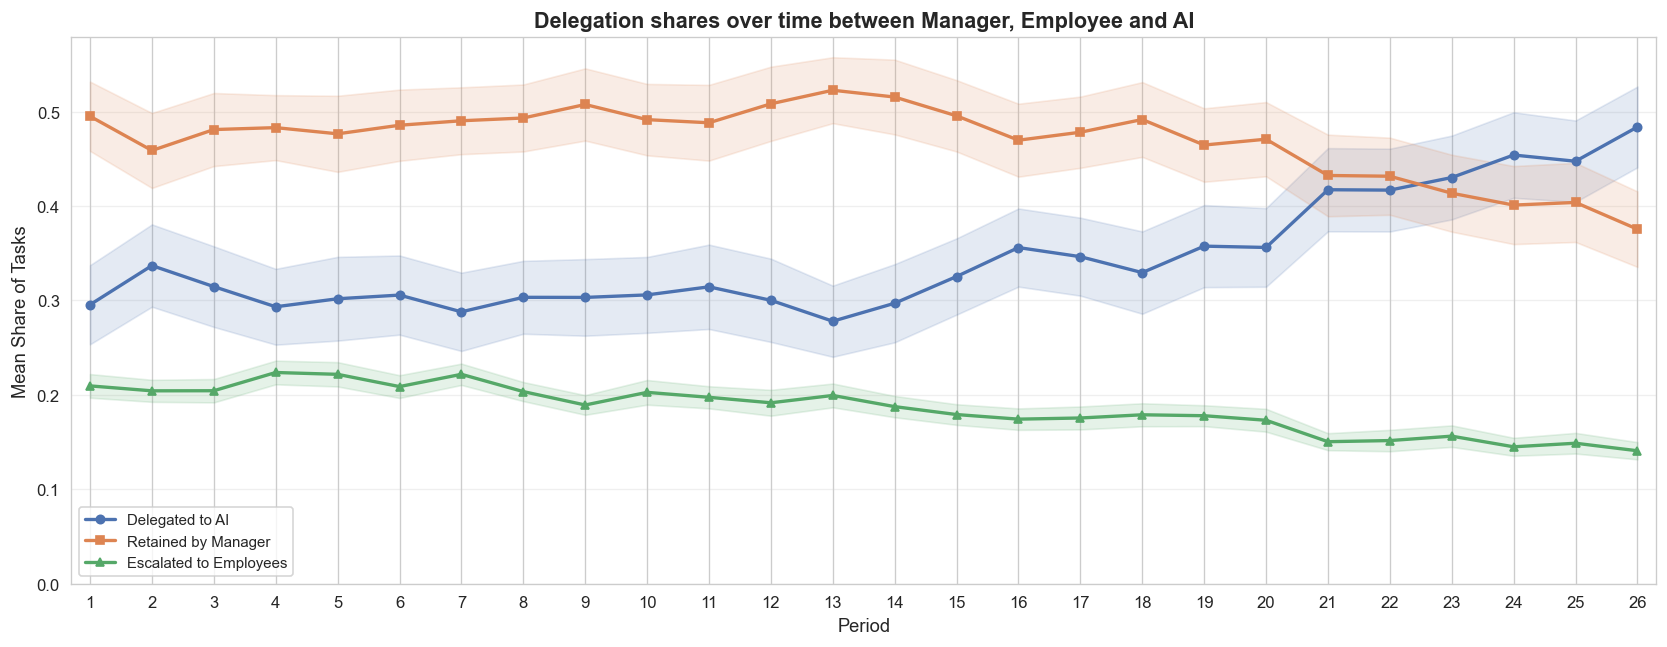

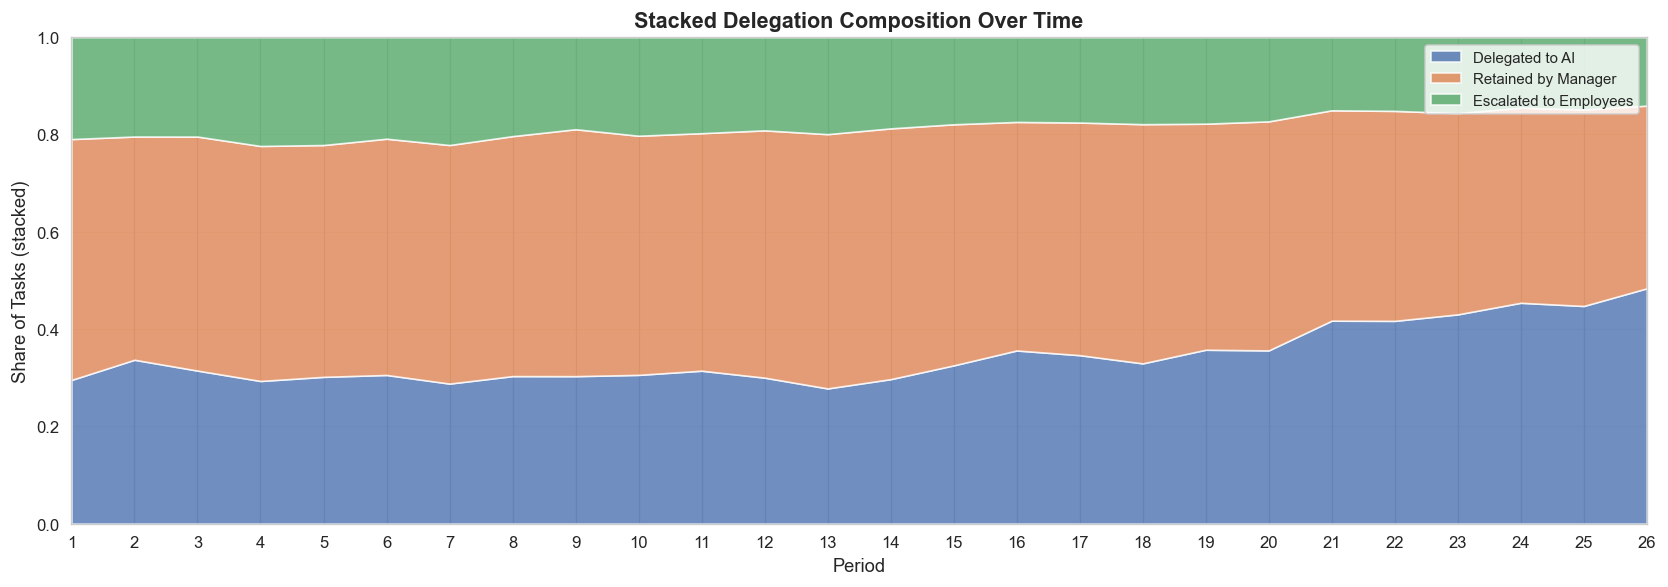

  AI delegation              ρ = +0.783  p = 0.0000  ***
  Manager retention          ρ = -0.545  p = 0.0040  **
  Employee escalation        ρ = -0.954  p = 0.0000  ***

════════════════════════════════════════════════════════════
✓ Section 5.4 complete: Temporal delegation trends visualised.
════════════════════════════════════════════════════════════


In [52]:
# ============================================================
# 5.4  Task Delegation Over Time
# ============================================================
# Aggregate authority shares across all managers per period,
# then plot temporal evolution with confidence bands.
# ============================================================

print("═══  Delegation Shares Over Time (All Managers)  ═══\n")

# ── 1. Period-level aggregation ──
time_agg = (task_agg
    .groupby("period_id")[["share_authority_ai", "share_authority_mgr", "share_authority_esc"]]
    .agg(["mean", "std", "count"]))

# Flatten multi-index columns
periods_t = time_agg.index.values

ai_mean  = time_agg[("share_authority_ai",  "mean")].values
mgr_mean = time_agg[("share_authority_mgr", "mean")].values
esc_mean = time_agg[("share_authority_esc", "mean")].values

ai_se  = time_agg[("share_authority_ai",  "std")].values / np.sqrt(time_agg[("share_authority_ai",  "count")].values)
mgr_se = time_agg[("share_authority_mgr", "std")].values / np.sqrt(time_agg[("share_authority_mgr", "count")].values)
esc_se = time_agg[("share_authority_esc", "std")].values / np.sqrt(time_agg[("share_authority_esc", "count")].values)

# Summary table
time_summary = pd.DataFrame({
    "Period": periods_t,
    "Delegated to AI (mean)": ai_mean,
    "Retained by Manager (mean)": mgr_mean,
    "Escalated to Employee (mean)": esc_mean,
}).set_index("Period")
display(time_summary.round(4))

# ── 2. Line plot with 95% CI bands ──
fig, ax = plt.subplots(figsize=(14, 5.5))

z = 1.96  # 95% CI

# Delegated to AI
ax.plot(periods_t, ai_mean, "-o", color="#4C72B0", linewidth=2, markersize=5,
        label="Delegated to AI")
ax.fill_between(periods_t, ai_mean - z * ai_se, ai_mean + z * ai_se,
                color="#4C72B0", alpha=0.15)

# Retained by Manager
ax.plot(periods_t, mgr_mean, "-s", color="#DD8452", linewidth=2, markersize=5,
        label="Retained by Manager")
ax.fill_between(periods_t, mgr_mean - z * mgr_se, mgr_mean + z * mgr_se,
                color="#DD8452", alpha=0.15)

# Escalated to Employees
ax.plot(periods_t, esc_mean, "-^", color="#55A868", linewidth=2, markersize=5,
        label="Escalated to Employees")
ax.fill_between(periods_t, esc_mean - z * esc_se, esc_mean + z * esc_se,
                color="#55A868", alpha=0.15)

ax.set_xlabel("Period", fontsize=11)
ax.set_ylabel("Mean Share of Tasks", fontsize=11)
ax.set_title("Delegation shares over time between Manager, Employee and AI",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="best")
ax.set_xlim(periods_t.min() - 0.3, periods_t.max() + 0.3)
ax.set_ylim(0, None)
ax.set_xticks(periods_t)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── 3. Stacked area chart ──
fig2, ax2 = plt.subplots(figsize=(14, 5))

ax2.stackplot(periods_t, ai_mean, mgr_mean, esc_mean,
              labels=["Delegated to AI", "Retained by Manager", "Escalated to Employees"],
              colors=["#4C72B0", "#DD8452", "#55A868"], alpha=0.8)

ax2.set_xlabel("Period", fontsize=11)
ax2.set_ylabel("Share of Tasks (stacked)", fontsize=11)
ax2.set_title("Stacked Delegation Composition Over Time",
              fontsize=13, fontweight="bold")
ax2.legend(loc="upper right", fontsize=9)
ax2.set_xlim(periods_t.min(), periods_t.max())
ax2.set_ylim(0, 1.0)
ax2.set_xticks(periods_t)
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── 4. Trend test (Spearman rank correlation with period) ──
from scipy.stats import spearmanr

for label, vals in [("AI delegation", ai_mean),
                    ("Manager retention", mgr_mean),
                    ("Employee escalation", esc_mean)]:
    rho, p_val = spearmanr(periods_t, vals)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    print(f"  {label:25s}  ρ = {rho:+.3f}  p = {p_val:.4f}  {sig}")

print("\n" + "═" * 60)
print("✓ Section 5.4 complete: Temporal delegation trends visualised.")
print("═" * 60)

<a id="13-model-summary-table"></a>
## 13. Model Summary Table
A single consolidated table reporting all key HMM parameters: emission means and standard deviations per state (original scale), initial state distribution (π), baseline transition matrix, posterior occupancy, and model fit statistics.

In [58]:

# ============================================================
# 15. Publication-Ready HMM Model Summary Table
#     NOTE: override_rate = 1 − ai_decision_authority_share by
#     construction, so we report only the two INDEPENDENT emission
#     dimensions: AI Decision Authority Share and Escalation Share.
#     Significance stars from cluster bootstrap p-values (if available).
# ============================================================

import numpy as np
import pandas as pd
from scipy.special import softmax
from IPython.display import display, HTML

# ── helpers ──
def _boot_stars(pval):
    """Return significance stars from a bootstrap p-value."""
    if not np.isfinite(pval):
        return ""
    if pval < 0.01: return "***"
    if pval < 0.05: return "**"
    if pval < 0.10: return "*"
    return ""

def _fmt_coef(val, pval, dec=5):
    """Format coefficient value with bootstrap significance stars."""
    return f"{val:.{dec}f}{_boot_stars(pval)}"

# Check which bootstrap results are available
_have_boot_W     = "p_W"    in dir() and p_W    is not None
_have_boot_beta  = "p_beta" in dir() and p_beta is not None
_have_boot_alpha = "p_alpha" in dir() and p_alpha is not None
_have_boot_mu    = "p_mu"   in dir() and p_mu   is not None
_have_se_W       = "se_W"   in dir() and se_W   is not None
_have_se_beta    = "se_beta" in dir() and se_beta is not None

_se_label = " with Bootstrap SEs" if _have_se_W else ""
_B_ok_local = _B_ok if "_B_ok" in dir() else 0
_B_label    = str(_B_ok_local) if _B_ok_local > 0 else "–"

# ── Gather all parameters ──
best_J_out = int(best_J)
label_order = [label_map[s] for s in state_order_1idx]
state_display_order = [s - 1 for s in state_order_1idx]

# Emissions (original scale)
mu_orig_    = data.y_scaler.inverse_transform(best_model.mu)
sigma_orig_ = np.exp(best_model.log_sigma) * data.y_scaler.scale_

# Initial state distribution
pi_ = softmax(best_model.logit_pi)

# Baseline transition matrix (X=0)
Q_base_ = np.zeros((best_J_out, best_J_out))
for j_ in range(best_J_out):
    Q_base_[j_] = softmax(best_model.alpha[j_])

# Posterior occupancy
gamma_flat = gamma.reshape(-1, best_J_out)
occ_  = gamma_flat.mean(axis=0)
cert_ = gamma_flat.max(axis=1).mean()

# ── Independent emission dimensions only (drop override_rate) ──
independent_dims = {
    0: ("ai_decision_authority_share", "AI Decision Authority Share"),
    2: ("share_authority_esc", "Escalation Share"),
}

# ── Panel A: Emission Parameters (independent dimensions only) ──
em_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    for d, (em_col, nice_name) in independent_dims.items():
        row = {
            "State": label_order[pos],
            "Emission Variable": nice_name,
            "Mean (μ)": round(float(mu_orig_[j0, d]), 4),
            "Std Dev (σ)": round(float(sigma_orig_[j0, d]), 4),
        }
        if _have_se_W:
            row["SE(μ)"] = round(float(se_mu[j0, d] * data.y_scaler.scale_[d]), 4)
        em_rows_.append(row)
panel_a = pd.DataFrame(em_rows_)

# ── Panel B: W coefficients with bootstrap significance stars ──
control_cols_full = [
    "task_complexity_index", "demand_volatility",
    "supply_disruption_count", "forecast_accuracy_mape",
    "decision_latency_avg", "target_difficulty",
    "performance_pressure_index", "recent_negative_shock",
]

control_nice = {
    "task_complexity_index":      "Task Complexity",
    "demand_volatility":          "Demand Volatility",
    "supply_disruption_count":    "Supply Disruptions",
    "forecast_accuracy_mape":     "Forecast Accuracy (MAPE)",
    "decision_latency_avg":       "Decision Latency",
    "target_difficulty":          "Target Difficulty",
    "performance_pressure_index": "Performance Pressure",
    "recent_negative_shock":      "Recent Negative Shock",
}

K_model_ = best_model.W.shape[2]
ctrl_cols_ = control_cols_full[:K_model_] if K_model_ <= len(control_cols_full) else \
             control_cols_full + [f"z_cov_{i}" for i in range(len(control_cols_full), K_model_)]

# W on original scale (for display)
W_orig_ = best_model.W.copy()
_have_z_scale = (hasattr(data, "z_scaler") and hasattr(data.z_scaler, "scale_")
                 and len(data.z_scaler.scale_) >= K_model_)
if _have_z_scale:
    W_orig_ = best_model.W / data.z_scaler.scale_[None, None, :K_model_]

# SE on original scale (same rescaling)
if _have_se_W and _have_z_scale:
    se_W_orig = se_W / data.z_scaler.scale_[None, None, :K_model_]
elif _have_se_W:
    se_W_orig = se_W.copy()
else:
    se_W_orig = None

# Build intercept (μ) pivot tables for each independent emission dim
mu_pivots_ = {}
for d, (em_col, nice_name) in independent_dims.items():
    row = {}
    for pos, s1 in enumerate(state_order_1idx):
        j0 = s1 - 1
        mu_val = float(mu_orig_[j0, d])
        if _have_boot_mu:
            mu_p = float(p_mu[j0, d])
            row[label_order[pos]] = _fmt_coef(mu_val, mu_p, dec=4)
        else:
            row[label_order[pos]] = f"{mu_val:.4f}"
    mu_pivots_[nice_name] = pd.DataFrame([row], index=["Intercept (μ)"])

# Build pivot tables WITH stars for each independent emission dim
w_pivots_ = {}
for d, (em_col, nice_name) in independent_dims.items():
    rows = []
    for pos, s1 in enumerate(state_order_1idx):
        j0 = s1 - 1
        for k, ctrl in enumerate(ctrl_cols_):
            w_val = float(W_orig_[j0, d, k])
            if _have_boot_W:
                w_p = float(p_W[j0, d, k])
                cell_text = _fmt_coef(w_val, w_p, dec=5)
            else:
                cell_text = f"{w_val:.5f}"
            rows.append({
                "State": label_order[pos],
                "Control Variable": control_nice.get(ctrl, ctrl),
                "value": cell_text,
            })
    sub_df = pd.DataFrame(rows)
    piv = sub_df.pivot(index="Control Variable", columns="State", values="value")
    piv = piv[label_order]
    w_pivots_[nice_name] = piv

# ── Panel C: Transition Covariate Coefficients (β) with bootstrap stars ──
P_model_ = best_model.beta.shape[2]
# Use the actual transition_cols from the kernel (defined in load_sequences)
_tc_full = transition_cols if "transition_cols" in dir() else [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "within_unit_ai_trajectory_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
    "transparency_x_operational",
    "transparency_x_temporal",
]
trans_cols_ = _tc_full[:P_model_]

transition_nice = {
    "within_unit_temporal_benchmark":       "Temporal Benchmark",
    "horizontal_peer_benchmark":            "Peer Benchmark",
    "within_unit_ai_trajectory_benchmark":  "AI Trajectory Benchmark",
    "threshold_benchmark":                  "Threshold Shock",
    "transparency_level_norm":              "Transparency Level (norm)",
    "transparency_x_operational":           "Transparency × Operational Gap",
    "transparency_x_temporal":              "Transparency × Temporal Benchmark",
}

beta_pivots_ = {}
for p_idx, cov in enumerate(trans_cols_):
    cov_nice = transition_nice.get(cov, cov)
    rows = []
    for fi, from_s in enumerate(state_order_1idx):
        fj = from_s - 1
        for ti, to_s in enumerate(state_order_1idx):
            tj = to_s - 1
            b_val = float(best_model.beta[fj, tj, p_idx])
            if _have_boot_beta:
                b_p = float(p_beta[fj, tj, p_idx])
                cell_text = _fmt_coef(b_val, b_p, dec=4)
            else:
                cell_text = f"{b_val:.4f}"
            rows.append({
                "From": label_order[fi],
                "To": label_order[ti],
                "value": cell_text,
            })
    sub_df = pd.DataFrame(rows)
    piv = sub_df.pivot(index="From", columns="To", values="value")
    piv = piv[label_order].reindex(label_order)
    beta_pivots_[cov_nice] = piv

# ── Panel C-alpha: Transition Intercept (α) ──
alpha_rows_ = []
for fi, from_s in enumerate(state_order_1idx):
    fj = from_s - 1
    for ti, to_s in enumerate(state_order_1idx):
        tj = to_s - 1
        a_val = float(best_model.alpha[fj, tj])
        if _have_boot_alpha:
            a_p = float(p_alpha[fj, tj])
            cell_text = _fmt_coef(a_val, a_p, dec=4)
        else:
            cell_text = f"{a_val:.4f}"
        alpha_rows_.append({
            "From": label_order[fi],
            "To": label_order[ti],
            "value": cell_text,
        })
alpha_piv_ = pd.DataFrame(alpha_rows_).pivot(
    index="From", columns="To", values="value")
alpha_piv_ = alpha_piv_[label_order].reindex(label_order)

# ── Panel D: Initial State Distribution ──
pi_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    pi_rows_.append({
        "State": label_order[pos],
        "π": round(float(pi_[j0]), 4),
    })
panel_d = pd.DataFrame(pi_rows_)

# ── Panel E: Baseline Transition Matrix ──
Q_ordered_ = Q_base_[np.ix_(state_display_order, state_display_order)]
panel_e = pd.DataFrame(
    np.round(Q_ordered_, 4),
    index=label_order,
    columns=label_order,
)
panel_e.index.name = "From \\ To"

# ── Panel F: Posterior State Occupancy ──
occ_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    occ_rows_.append({
        "State": label_order[pos],
        "Occupancy (%)": round(float(occ_[j0]) * 100, 2),
    })
panel_f = pd.DataFrame(occ_rows_)

# ── Panel G: Model Fit ──
n_indep_dims = len(independent_dims)
fit_rows_ = [
    {"Metric": "Log-Likelihood",              "Value": f"{ll_total:.2f}"},
    {"Metric": "AIC",                         "Value": f"{aic:.2f}"},
    {"Metric": "BIC",                         "Value": f"{bic:.2f}"},
    {"Metric": "No. Parameters",              "Value": f"{k_params}"},
    {"Metric": "No. Observations",            "Value": f"{n_obs_total:,}"},
    {"Metric": "No. States (J)",              "Value": f"{best_J_out}"},
    {"Metric": "No. Emissions (D, fitted)",   "Value": f"{len(emission_cols)}"},
    {"Metric": "No. Independent Emissions",   "Value": f"{n_indep_dims}"},
    {"Metric": "No. Controls (K)",            "Value": f"{K_model_}"},
    {"Metric": "No. Transition Covariates (P)", "Value": f"{P_model_}"},
    {"Metric": "Mean Posterior Certainty",    "Value": f"{cert_:.3f}"},
    {"Metric": "Bootstrap Replications (B)",  "Value": _B_label},
]
panel_g = pd.DataFrame(fit_rows_)

# ── Render as styled HTML ──
html_parts = []

html_parts.append("<h3>Table 1: NH-HMM Parameter Estimates</h3>")
html_parts.append("<br><b>Panel A: Emission Means and Standard Deviations "
                  "(Independent Dimensions)</b>")
html_parts.append(
    panel_a.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

html_parts.append(f"<br><b>Panel B: Emission Equation Coefficients "
                  f"(Original Scale{_se_label})</b>")
for em_name in w_pivots_:
    html_parts.append(f"<br><i>&nbsp;&nbsp;&nbsp;&nbsp;{em_name} — Intercept (&mu;)</i>")
    html_parts.append(
        mu_pivots_[em_name].to_html(border=1, classes="table table-sm", escape=False)
    )
    html_parts.append(f"<br><i>&nbsp;&nbsp;&nbsp;&nbsp;{em_name} — Control variable coefficients (W)</i>")
    html_parts.append(
        w_pivots_[em_name].to_html(border=1, classes="table table-sm", escape=False)
    )

_beta_note = " with Bootstrap SEs" if _have_boot_beta else ""
html_parts.append(f"<br><b>Panel C: Transition Equation Coefficients "
                  f"(Scaled X{_beta_note})</b>")
html_parts.append("<br><i>&nbsp;&nbsp;Intercept (&alpha;)</i>")
html_parts.append(
    alpha_piv_.to_html(border=1, classes="table table-sm", escape=False)
)
for cov_nice_str, piv in beta_pivots_.items():
    html_parts.append(f"<br><i>&nbsp;&nbsp;Covariate: {cov_nice_str}</i>")
    html_parts.append(
        piv.to_html(border=1, classes="table table-sm", escape=False)
    )

html_parts.append("<br><b>Panel D: Initial State Distribution (&pi;)</b>")
html_parts.append(
    panel_d.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

html_parts.append("<br><b>Panel E: Baseline Transition Matrix (X = 0)</b>")
html_parts.append(
    panel_e.to_html(border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

html_parts.append("<br><b>Panel F: Posterior State Occupancy</b>")
html_parts.append(
    panel_f.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.2f}")
)

html_parts.append("<br><b>Panel G: Model Fit Statistics</b>")
html_parts.append(
    panel_g.to_html(index=False, border=1, classes="table table-sm")
)

# ── Notes ──
se_note = ""
if _have_boot_W:
    se_note = (
        "Significance: ∗ <i>p</i> &lt; 0.10; ∗∗ <i>p</i> &lt; 0.05; "
        "∗∗∗ <i>p</i> &lt; 0.01. "
        "<i>p</i>-values are computed via the cluster bootstrap "
        f"(B = {_B_label} replications, resampling whole manager "
        "sequences with replacement). "
        "Stars reflect the bootstrap percentile <i>p</i>-value: "
        "<i>p</i> = 2 min(fraction of bootstrap estimates &le; 0,&ensp;"
        "fraction &ge; 0). "
    )

html_parts.append(
    "<p style='font-size:0.85em; color:#555; margin-top:8px'>"
    f"<i>Notes.</i> {se_note}"
    "The model was fitted with D=3 emission dimensions, but "
    "override_rate = 1 &minus; ai_decision_authority_share by construction, "
    "so only the two independent dimensions (AI Decision Authority Share, "
    "Escalation Share) are reported. "
    "Emission means (&mu;) and standard deviations (&sigma;) are on the "
    "original (unscaled) variable scale. W coefficients represent the "
    "marginal effect of each control variable on the emission mean within each state "
    "(original-scale units per one-unit change in the control). "
    "&mu; coefficients are the emission intercepts (original scale). "
    "&beta; coefficients are on the scaled-X scale (log-odds of transition). "
    "&alpha; coefficients are the transition intercepts (baseline log-odds at X&nbsp;=&nbsp;0). "
    "Transition probabilities (Panel E) are computed at X = 0. "
    "Posterior occupancy is the mean &gamma;<sub>it</sub> across all observations. "
    "States are labelled by ascending AI decision authority share: "
    "Aversion (lowest), Transitionary (middle), Appreciation (highest)."
    "</p>"
)

display(HTML("\n".join(html_parts)))

print("\n✓ Table 1 rendered (7 panels).")
if not _have_boot_W:
    print("  ℹ  No bootstrap p-values available — significance stars omitted.")
    print("     Run the bootstrap cell to add significance notation.")


State,Emission Variable,Mean (μ),Std Dev (σ)
Aversion,AI Decision Authority Share,0.3491,0.0279
Aversion,Escalation Share,0.1542,0.0536
Transitionary,AI Decision Authority Share,0.4161,0.0279
Transitionary,Escalation Share,0.1841,0.0537
Appreciation,AI Decision Authority Share,0.4851,0.0284
Appreciation,Escalation Share,0.2181,0.0601
,Aversion,Transitionary,Appreciation
Intercept (μ),0.3491,0.4161,0.4851
State,Aversion,Transitionary,Appreciation
Control Variable,,,



✓ Table 1 rendered (7 panels).
  ℹ  No bootstrap p-values available — significance stars omitted.
     Run the bootstrap cell to add significance notation.


P = 7 transition covariates
  transparency_level_norm    available: True
  transparency_x_operational available: True
  transparency_x_temporal    available: True

═════════════════════════════════════════════════════════════════
A. Effective slope on Temporal Benchmark by Transparency Level
   d(logit_ij)/d(temporal) = β₀ + β₆·(L/3)
═════════════════════════════════════════════════════════════════


,β₀(temporal),β₆(transp×temporal),Eff. slope L0,Eff. slope L1,Eff. slope L2,Eff. slope L3
From → To,,,,,,
Aversion → Aversion,-0.0135,-0.0021,-0.0135,-0.0142,-0.0149,-0.0156
Aversion → Transitionary,0.2098,-0.0923,0.2098,0.1790,0.1482,0.1175
Aversion → Appreciation,-0.1957,0.0930,-0.1957,-0.1647,-0.1337,-0.1027
Transitionary → Aversion,0.0639,-0.1249,0.0639,0.0222,-0.0194,-0.0610
Transitionary → Transitionary,0.0579,-0.1292,0.0579,0.0148,-0.0282,-0.0713
Transitionary → Appreciation,-0.1213,0.2541,-0.1213,-0.0366,0.0481,0.1328
Appreciation → Aversion,0.0742,0.0631,0.0742,0.0953,0.1163,0.1374
Appreciation → Transitionary,-0.0850,-0.1194,-0.0850,-0.1248,-0.1646,-0.2044
Appreciation → Appreciation,0.0121,0.0562,0.0121,0.0308,0.0495,0.0682



• Positive slope = better temporal performance raises this transition's log-odds.
• β₆ > 0 : transparency AMPLIFIES the performance→transition signal.
• β₆ < 0 : transparency DAMPENS  the performance→transition signal.

── Direct log-odds effect of transparency_level_norm (β₄) ──


,β₄(transp_norm)
From → To,
Aversion → Aversion,0.0246
Aversion → Transitionary,0.1048
Aversion → Appreciation,-0.1294
Transitionary → Aversion,0.1654
Transitionary → Transitionary,-0.0939
Transitionary → Appreciation,-0.0741
Appreciation → Aversion,-0.0064
Appreciation → Transitionary,-0.0719
Appreciation → Appreciation,0.0777



── Operational-gap interaction β₅(transp×oper_gap) ──


...

,Aversion,Transitionary,Appreciation
L1 From \ To,,,
Aversion,0.2921,0.5130,0.1950
Transitionary,0.2797,0.4950,0.2253
Appreciation,0.2335,0.5005,0.2660



── Transparency Level 2  (transp_norm = 0.667) ──


,Aversion,Transitionary,Appreciation
L2 From \ To,,,
Aversion,0.2896,0.5217,0.1887
Transitionary,0.3020,0.4691,0.2289
Appreciation,0.2349,0.4760,0.2890



── Transparency Level 3  (transp_norm = 1.000) ──


,Aversion,Transitionary,Appreciation
L3 From \ To,,,
Aversion,0.2870,0.5304,0.1826
Transitionary,0.3250,0.4431,0.2319
Appreciation,0.2356,0.4513,0.3131


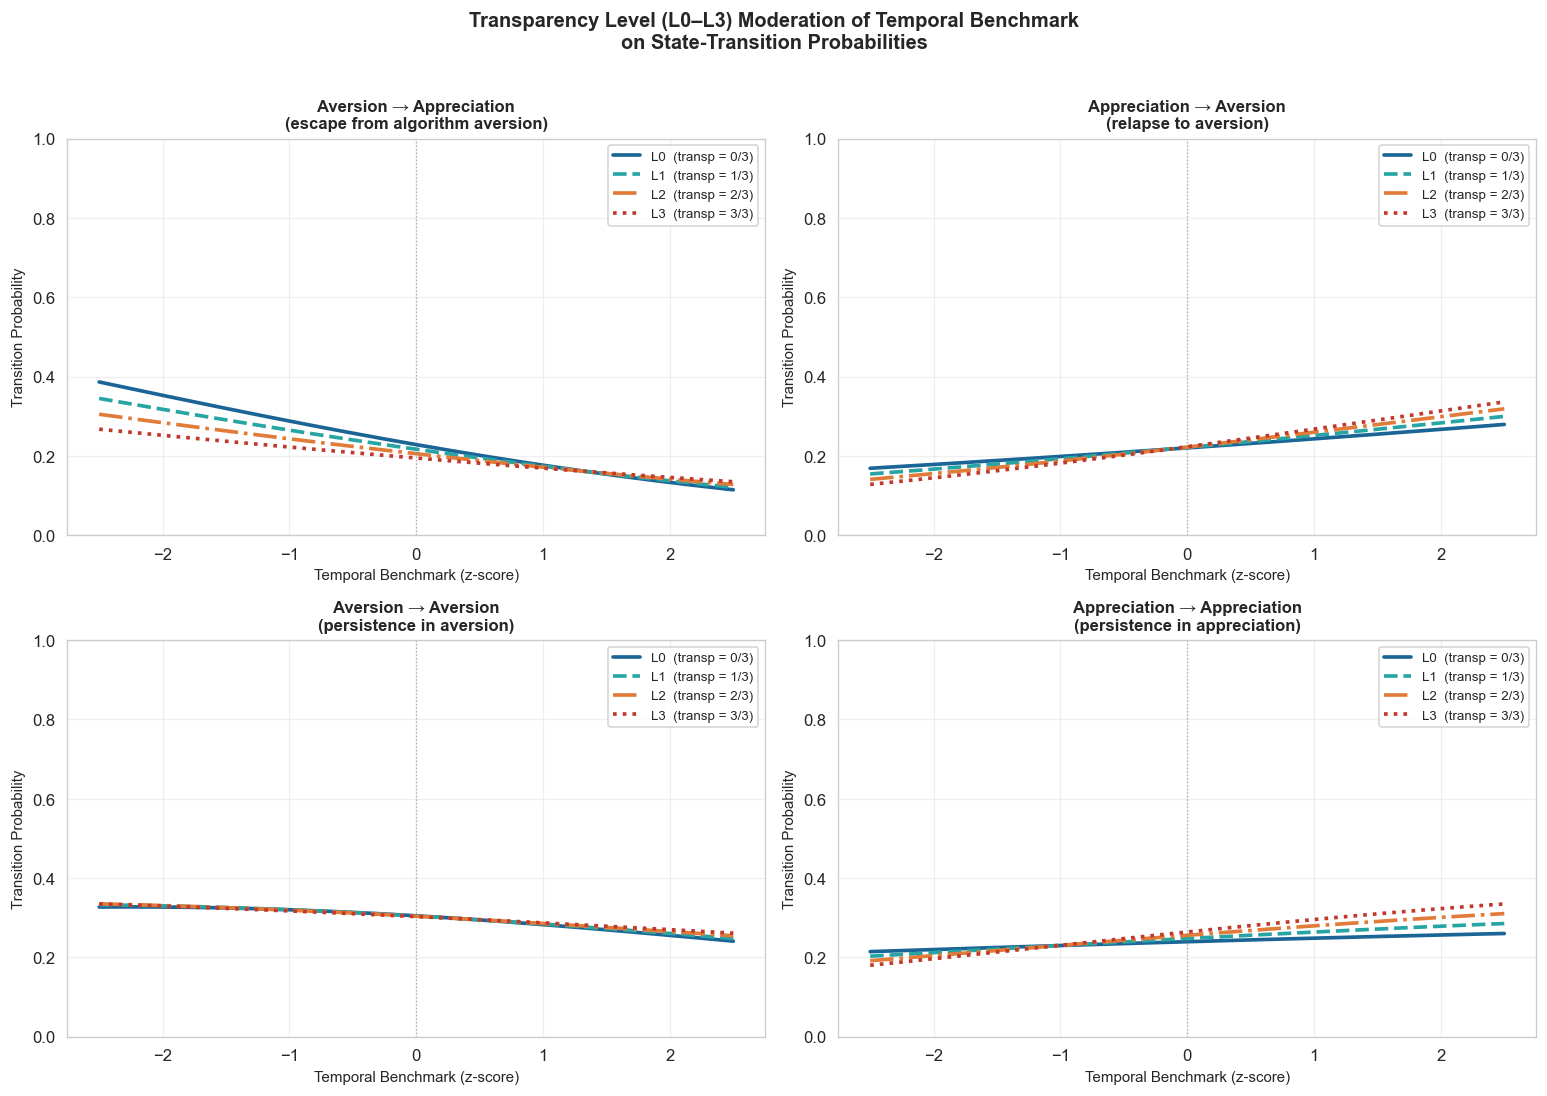

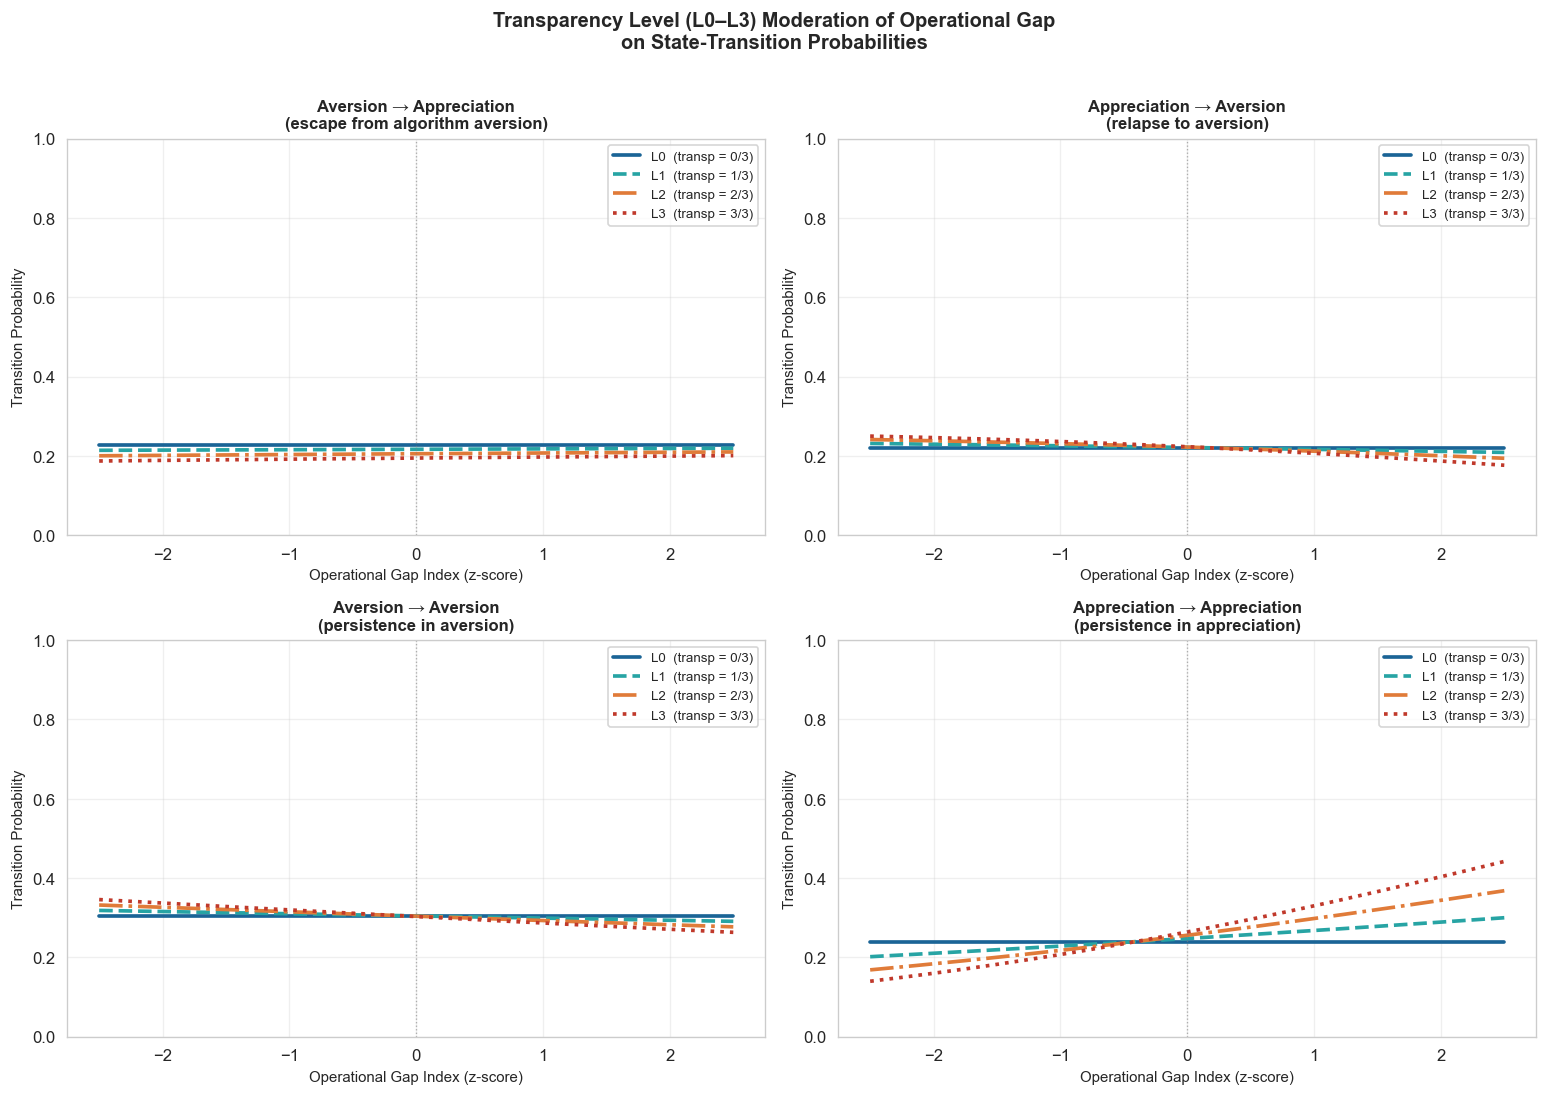


═════════════════════════════════════════════════════════════════
D. ΔQ = Q(L3) − Q(L0)  at perf = +0.5 SD
═════════════════════════════════════════════════════════════════


,Aversion,Transitionary,Appreciation
From \ To,,,
Aversion,-0.0074,0.0262,-0.0187
Transitionary,0.0668,-0.0776,0.0108
Appreciation,0.0043,-0.0733,0.0690


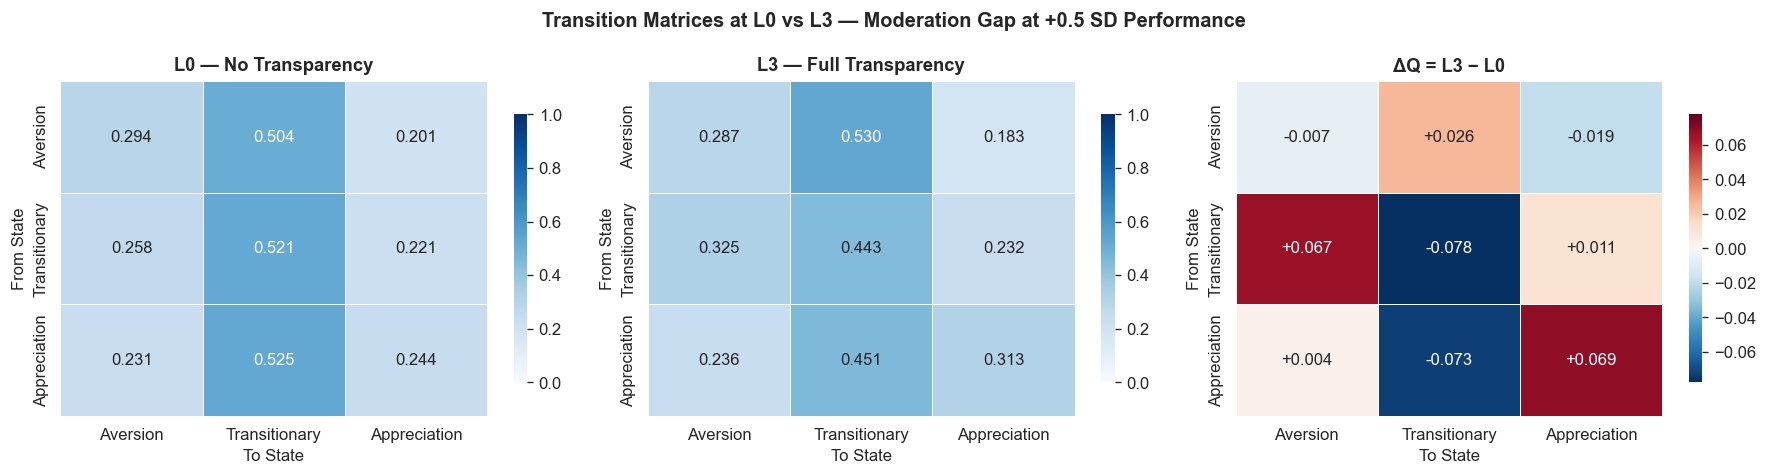


═════════════════════════════════════════════════════════════════
E. Transparency Moderation Summary  (perf = +0.5 SD)
═════════════════════════════════════════════════════════════════


,P(L0),P(L1),P(L2),P(L3),ΔP (L3−L0),Monotone,Direction
Transition,,,,,,,
Aversion → Aversion,0.2944,0.2921,0.2896,0.2870,-0.0074,yes,↓ falls with transparency
Aversion → Transitionary,0.5042,0.5130,0.5217,0.5304,0.0262,yes,↑ rises with transparency
Aversion → Appreciation,0.2014,0.1950,0.1887,0.1826,-0.0187,yes,↓ falls with transparency
Transitionary → Aversion,0.2582,0.2797,0.3020,0.3250,0.0668,yes,↑ rises with transparency
Transitionary → Transitionary,0.5207,0.4950,0.4691,0.4431,-0.0776,yes,↓ falls with transparency
Transitionary → Appreciation,0.2211,0.2253,0.2289,0.2319,0.0108,yes,↑ rises with transparency
Appreciation → Aversion,0.2313,0.2335,0.2349,0.2356,0.0043,yes,↑ rises with transparency
Appreciation → Transitionary,0.5246,0.5005,0.4760,0.4513,-0.0733,yes,↓ falls with transparency
Appreciation → Appreciation,0.2441,0.2660,0.2890,0.3131,0.0690,yes,↑ rises with transparency



Interpretation guide:
  ΔP > 0  → transparency steers managers TOWARD this transition
  ΔP < 0  → transparency steers managers AWAY from this transition
  Monotone = yes: effect accumulates linearly across L0→L1→L2→L3
  Monotone = no : non-linear (sign-reversal or U-shape across levels)

Top-5 transitions most affected by transparency (by │ΔP│):


,ΔP (L3−L0),Direction
Transition,,
Transitionary → Transitionary,-0.0776,↓ falls with transparency
Appreciation → Transitionary,-0.0733,↓ falls with transparency
Appreciation → Appreciation,0.0690,↑ rises with transparency
Transitionary → Aversion,0.0668,↑ rises with transparency
Aversion → Transitionary,0.0262,↑ rises with transparency



═════════════════════════════════════════════════════════════════
✓ §16 complete: Transparency moderation analysis (L0–L3).
  Panels A–E show how transparency reshapes performance-driven
  state transitions through three β channels:
  β₄ (direct), β₅ (×oper. gap), β₆ (×temporal benchmark).
═════════════════════════════════════════════════════════════════


In [61]:

# ============================================================
# 16. Moderation Effects of Transparency Level (L0–L3)
#     on the Performance → State-Transition Relationship
#
#  The model's 7 transition covariates (Stage 2 refit) are:
#   [0] within_unit_temporal_benchmark       (performance signal)
#   [1] horizontal_peer_benchmark
#   [2] within_unit_ai_trajectory_benchmark
#   [3] threshold_benchmark
#   [4] transparency_level_norm  (= transparency_level / 3)
#   [5] transparency_x_operational  (= norm × kpi_operational_gap)
#   [6] transparency_x_temporal     (= norm × temporal_benchmark)
#
#  Moderation works through TWO channels in the transition equation:
#    logit(i→j) = α[i,j]
#               + β[4]·(L/3)                       direct effect
#               + β[0]·temporal + β[6]·(L/3)·temporal   interaction
#               + β[5]·(L/3)·oper_gap              interaction
#
#  The EFFECTIVE slope on temporal performance at level L is:
#    β_eff(temporal) = β[0]  +  β[6]·(L/3)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

_J      = best_model.mu.shape[0]
P_now   = best_model.beta.shape[2]
_labels = [label_map[s] for s in state_order_1idx]
_disp   = [s - 1 for s in state_order_1idx]   # 0-indexed, aversion-first

# ── Indices (hard-coded to match Stage-2 training data) ──
# These are positions in the transition covariate vector X[n,t,:]
_I_TEMP  = 0   # within_unit_temporal_benchmark
_I_PEER  = 1   # horizontal_peer_benchmark
_I_AI    = 2   # within_unit_ai_trajectory_benchmark
_I_THRSH = 3   # threshold_benchmark
_I_TNORM = 4   # transparency_level_norm    (L/3)
_I_TXOP  = 5   # transparency_x_operational (L/3 × oper_gap)
_I_TXTMP = 6   # transparency_x_temporal    (L/3 × temporal)

_HAS_TNORM = (P_now > _I_TNORM)
_HAS_TXOP  = (P_now > _I_TXOP)
_HAS_TXTMP = (P_now > _I_TXTMP)

print(f"P = {P_now} transition covariates")
print(f"  transparency_level_norm    available: {_HAS_TNORM}")
print(f"  transparency_x_operational available: {_HAS_TXOP}")
print(f"  transparency_x_temporal    available: {_HAS_TXTMP}")

TRANSP_LEVELS = [0, 1, 2, 3]
TRANSP_NORMS  = [L / 3.0 for L in TRANSP_LEVELS]

# ── helper: build X vector (all unspecified covariates = 0 = mean) ──
def _x_at(L_int, temp_bench=0.0, oper_gap=0.0):
    tn = L_int / 3.0
    x = np.zeros(P_now)
    x[_I_TEMP] = temp_bench
    if _HAS_TNORM: x[_I_TNORM] = tn
    if _HAS_TXOP:  x[_I_TXOP]  = tn * oper_gap
    if _HAS_TXTMP: x[_I_TXTMP] = tn * temp_bench
    return x

# ── helper: Q matrix from X vector ──
def _Q_from_x(x_vec):
    logit = best_model.alpha + np.einsum("ijp,p->ij", best_model.beta, x_vec)
    return np.array([softmax(logit[i]) for i in range(_J)])

# ═══════════════════════════════════════════════════════════════════
# A. Effective performance slopes: β_eff = β[temp] + β[transp×temp]·(L/3)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("A. Effective slope on Temporal Benchmark by Transparency Level")
print("   d(logit_ij)/d(temporal) = β₀ + β₆·(L/3)")
print("═"*65)

b_temp  = best_model.beta[:, :, _I_TEMP]
b_txtmp = best_model.beta[:, :, _I_TXTMP] if _HAS_TXTMP else np.zeros((_J, _J))

slope_rows = []
for fi, from_s in enumerate(state_order_1idx):
    fj = from_s - 1
    for ti, to_s in enumerate(state_order_1idx):
        tj = to_s - 1
        base = float(b_temp[fj, tj])
        mod  = float(b_txtmp[fj, tj])
        row = {
            "From → To":           f"{_labels[fi]} → {_labels[ti]}",
            "β₀(temporal)":        round(base, 4),
            "β₆(transp×temporal)": round(mod, 4),
        }
        for L, tn in zip(TRANSP_LEVELS, TRANSP_NORMS):
            row[f"Eff. slope L{L}"] = round(base + mod * tn, 4)
        slope_rows.append(row)

slope_df = pd.DataFrame(slope_rows).set_index("From → To")
display(slope_df)
print("\n• Positive slope = better temporal performance raises this transition's log-odds.")
print("• β₆ > 0 : transparency AMPLIFIES the performance→transition signal.")
print("• β₆ < 0 : transparency DAMPENS  the performance→transition signal.")

# ── direct transparency-level effect (β₄) ──
print("\n── Direct log-odds effect of transparency_level_norm (β₄) ──")
if _HAS_TNORM:
    b_tn = best_model.beta[:, :, _I_TNORM]
    tn_rows = []
    for fi, from_s in enumerate(state_order_1idx):
        fj = from_s - 1
        for ti, to_s in enumerate(state_order_1idx):
            tj = to_s - 1
            tn_rows.append({
                "From → To": f"{_labels[fi]} → {_labels[ti]}",
                "β₄(transp_norm)": round(float(b_tn[fj, tj]), 4),
            })
    display(pd.DataFrame(tn_rows).set_index("From → To"))

# ── operational-gap interaction (β₅) ──
print("\n── Operational-gap interaction β₅(transp×oper_gap) ──")
if _HAS_TXOP:
    b_op = best_model.beta[:, :, _I_TXOP]
    op_rows = []
    for fi, from_s in enumerate(state_order_1idx):
        fj = from_s - 1
        for ti, to_s in enumerate(state_order_1idx):
            tj = to_s - 1
            op_rows.append({
                "From → To": f"{_labels[fi]} → {_labels[ti]}",
                "β₅(transp×oper_gap)": round(float(b_op[fj, tj]), 4),
            })
    display(pd.DataFrame(op_rows).set_index("From → To"))

# ═══════════════════════════════════════════════════════════════════
# B. Full Q at each level (temporal = +0.5 SD, oper_gap = +0.5 SD)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("B. Q matrix at each transparency level")
print("   (temporal benchmark = +0.5 z, operational gap = +0.5 z)")
print("═"*65)

PERF = 0.5
Q_by_level = {}
for L in TRANSP_LEVELS:
    x    = _x_at(L, temp_bench=PERF, oper_gap=PERF)
    Q_r  = _Q_from_x(x)
    Q_ord = Q_r[np.ix_(_disp, _disp)]
    Q_by_level[L] = Q_ord
    df_q = pd.DataFrame(np.round(Q_ord, 4), index=_labels, columns=_labels)
    df_q.index.name = f"L{L}  From \\ To"
    print(f"\n── Transparency Level {L}  (transp_norm = {L/3:.3f}) ──")
    display(df_q)

# ═══════════════════════════════════════════════════════════════════
# C. Probability curves: key transitions vs temporal benchmark
# ═══════════════════════════════════════════════════════════════════
perf_grid = np.linspace(-2.5, 2.5, 150)
palette   = {0: "#1a6496", 1: "#27a4a4", 2: "#e07b39", 3: "#c0392b"}
ls_map    = {0: "-", 1: "--", 2: "-.", 3: ":"}

focus_pairs = [
    (0, 2, "Aversion → Appreciation\n(escape from algorithm aversion)"),
    (2, 0, "Appreciation → Aversion\n(relapse to aversion)"),
    (0, 0, "Aversion → Aversion\n(persistence in aversion)"),
    (2, 2, "Appreciation → Appreciation\n(persistence in appreciation)"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()
for ax_i, (from_idx, to_idx, title) in enumerate(focus_pairs):
    ax = axes[ax_i]
    from_d = _disp[from_idx]
    to_d   = _disp[to_idx]
    for L in TRANSP_LEVELS:
        probs = [float(_Q_from_x(_x_at(L, temp_bench=p, oper_gap=0.0))[from_d, to_d])
                 for p in perf_grid]
        ax.plot(perf_grid, probs, lw=2.2,
                color=palette[L], ls=ls_map[L],
                label=f"L{L}  (transp = {L}/3)")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Temporal Benchmark (z-score)", fontsize=9)
    ax.set_ylabel("Transition Probability", fontsize=9)
    ax.set_ylim(0, 1)
    ax.axvline(0, color="grey", lw=0.8, ls=":", alpha=0.6)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle(
    "Transparency Level (L0–L3) Moderation of Temporal Benchmark\n"
    "on State-Transition Probabilities",
    fontsize=12, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

# Operational-gap curves
fig3, axes3 = plt.subplots(2, 2, figsize=(13, 9))
axes3 = axes3.ravel()
oper_grid = np.linspace(-2.5, 2.5, 150)
for ax_i, (from_idx, to_idx, title) in enumerate(focus_pairs):
    ax = axes3[ax_i]
    from_d = _disp[from_idx]
    to_d   = _disp[to_idx]
    for L in TRANSP_LEVELS:
        probs = [float(_Q_from_x(_x_at(L, temp_bench=0.0, oper_gap=og))[from_d, to_d])
                 for og in oper_grid]
        ax.plot(oper_grid, probs, lw=2.2,
                color=palette[L], ls=ls_map[L],
                label=f"L{L}  (transp = {L}/3)")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Operational Gap Index (z-score)", fontsize=9)
    ax.set_ylabel("Transition Probability", fontsize=9)
    ax.set_ylim(0, 1)
    ax.axvline(0, color="grey", lw=0.8, ls=":", alpha=0.6)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig3.suptitle(
    "Transparency Level (L0–L3) Moderation of Operational Gap\n"
    "on State-Transition Probabilities",
    fontsize=12, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# D. Heatmaps: Q(L0), Q(L3), ΔQ = Q(L3) − Q(L0)
# ═══════════════════════════════════════════════════════════════════
delta_Q  = Q_by_level[3] - Q_by_level[0]
delta_df = pd.DataFrame(np.round(delta_Q, 4), index=_labels, columns=_labels)
delta_df.index.name = "From \\ To"

print("\n" + "═"*65)
print("D. ΔQ = Q(L3) − Q(L0)  at perf = +0.5 SD")
print("═"*65)
display(delta_df)

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
for ax_i, (L, ttl) in enumerate([(0, "L0 — No Transparency"),
                                  (3, "L3 — Full Transparency"),
                                  (None, "ΔQ = L3 − L0")]):
    ax = axes2[ax_i]
    if L is not None:
        mat = Q_by_level[L]
        vmin, vmax, cmap, fmt = 0, 1, "Blues", ".3f"
    else:
        mat = delta_Q
        amax = max(abs(delta_Q.min()), abs(delta_Q.max()), 0.02)
        vmin, vmax, cmap, fmt = -amax, amax, "RdBu_r", "+.3f"
    sns.heatmap(
        pd.DataFrame(np.round(mat, 3), index=_labels, columns=_labels),
        ax=ax, annot=True, fmt=fmt, cmap=cmap,
        vmin=vmin, vmax=vmax, linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(ttl, fontsize=11, fontweight="bold")
    ax.set_xlabel("To State"); ax.set_ylabel("From State")

fig2.suptitle(
    "Transition Matrices at L0 vs L3 — Moderation Gap at +0.5 SD Performance",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# E. Summary: signed moderation effect across all 9 transition pairs
# ═══════════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("E. Transparency Moderation Summary  (perf = +0.5 SD)")
print("═"*65)

summary_rows = []
for fi in range(len(_labels)):
    for ti in range(len(_labels)):
        vals = [float(Q_by_level[L][fi, ti]) for L in TRANSP_LEVELS]
        delta = vals[3] - vals[0]
        mono  = all(vals[i] <= vals[i+1] for i in range(3)) or \
                all(vals[i] >= vals[i+1] for i in range(3))
        if abs(delta) < 2e-4:
            direction = "≈ no change"
        elif delta > 0:
            direction = "↑ rises with transparency"
        else:
            direction = "↓ falls with transparency"
        summary_rows.append({
            "Transition":  f"{_labels[fi]} → {_labels[ti]}",
            "P(L0)": round(vals[0], 4),
            "P(L1)": round(vals[1], 4),
            "P(L2)": round(vals[2], 4),
            "P(L3)": round(vals[3], 4),
            "ΔP (L3−L0)": round(delta, 4),
            "Monotone": "yes" if mono else "no",
            "Direction": direction,
        })

summary_df = pd.DataFrame(summary_rows).set_index("Transition")
display(summary_df)

print("\nInterpretation guide:")
print("  ΔP > 0  → transparency steers managers TOWARD this transition")
print("  ΔP < 0  → transparency steers managers AWAY from this transition")
print("  Monotone = yes: effect accumulates linearly across L0→L1→L2→L3")
print("  Monotone = no : non-linear (sign-reversal or U-shape across levels)")

# ── Magnitude ranking ──
summary_df["│ΔP│"] = summary_df["ΔP (L3−L0)"].abs()
top5 = summary_df.nlargest(5, "│ΔP│")[["ΔP (L3−L0)", "Direction"]].drop(columns="│ΔP│", errors="ignore")
print("\nTop-5 transitions most affected by transparency (by │ΔP│):")
display(top5)

print("\n" + "═"*65)
print("✓ §16 complete: Transparency moderation analysis (L0–L3).")
print("  Panels A–E show how transparency reshapes performance-driven")
print("  state transitions through three β channels:")
print("  β₄ (direct), β₅ (×oper. gap), β₆ (×temporal benchmark).")
print("═"*65)
